# Proyecto Integrador de Ciencia de Datos — **Fase 1**
## Inasistencia escolar en la adolescencia paraguaya: magnitud, motivos declarados y brechas territoriales (2022–2025)

---

| | |
|---|---|
| **Asignatura** | Data Science |
| **Fase** | 1 de 3 — Ponderación 30 % |
| **Integrantes** | Matías Morínigo · César Vielman · Iván Paredes |
| **Fecha de entrega** | Martes 15 de septiembre |
| **Fuente** | Encuesta Permanente de Hogares Continua (EPHC) — Dirección General de Estadística, Encuestas y Censos (DGEEC), Paraguay |
| **Archivos** | `REG02_EPHC_ANUAL_2022.csv` · `_2023.csv` · `_2024.csv` · `_2025.csv` (registro de personas, Sección 4 — Educación) |

---

## Por qué se cambió la fuente de datos

La propuesta original de este proyecto preguntaba por los **factores institucionales** (servicios básicos,
infraestructura) asociados al **abandono escolar** entre 2015 y 2024, usando registros administrativos del
Ministerio de Educación y Ciencias (MEC). Al inventariar los archivos efectivamente disponibles en el portal
del MEC se comprobó que:

1. Los datasets de matrícula del MEC cubren un único año lectivo (2023) en el corte descargado.
2. **Ningún dataset del MEC contiene una variable de abandono, deserción o repitencia.**
3. Las variables de servicios básicos existen (`servicios_basicos` de FONACIDE), pero atadas a establecimientos
   priorizados para inversión, no al universo completo de instituciones ni a una serie temporal comparable.

La **EPHC de la DGEEC**, en cambio, sí trae —todos los años, con metodología estable— la pregunta **ED08**
(si la persona asiste actualmente) y, crucialmente, **ED10**: *"¿Por qué no asiste o dejó de asistir?"*, con
el motivo declarado por el propio hogar. Es la variable de abandono que la propuesta original necesitaba y
que el MEC no publica en datos abiertos. El costo de este cambio es real y se declara sin rodeos: la unidad
de análisis deja de ser el *establecimiento* y pasa a ser la *persona dentro de un hogar*, con un diseño
muestral complejo que exige usar el factor de expansión (`FEX`) en todo cálculo descriptivo.

> Si en el futuro se consigue el dataset `servicios_basicos` del MEC a nivel de establecimiento y con
> cobertura nacional, se podría intentar una estimación de disponibilidad de servicios **por departamento**
> y cruzarla con las tasas de inasistencia calculadas aquí. Esa vía queda anotada como trabajo futuro.


### Cómo usar este notebook

1. Los CSV (`REG02_EPHC_ANUAL_2022.csv` … `_2025.csv`) van en `data/raw/`, sin modificar.
2. `Kernel → Restart & Run All`. El notebook corre de principio a fin y regenera `data/processed/dataset_fase1.parquet`.
3. Debajo de cada gráfico (G1–G8) está la lectura que hicimos de ese resultado.
4. Ninguna transformación se hace a mano. Todo queda documentado en la bitácora de limpieza (Etapa 3.6).


---

## 0. Configuración y reproducibilidad

In [1]:
# ============================================================================
# Imports y configuración global
# ============================================================================
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

SEMILLA = 42
np.random.seed(SEMILLA)

RAIZ     = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DIR_RAW  = RAIZ / 'data' / 'raw'
DIR_PROC = RAIZ / 'data' / 'processed'
DIR_FIG  = RAIZ / 'output' / 'figuras'
DIR_TAB  = RAIZ / 'output' / 'tablas'
for _d in (DIR_RAW, DIR_PROC, DIR_FIG, DIR_TAB):
    _d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110, 'savefig.dpi': 200,
                     'savefig.bbox': 'tight', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'font.size': 10})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

print('Python:', sys.version.split()[0], '| pandas:', pd.__version__, '| numpy:', np.__version__)
print('Raíz  :', RAIZ)

Python: 3.12.4 | pandas: 3.0.5 | numpy: 2.5.3
Raíz  : /Users/ivanparedesozuna/Developer/proyecto-ds-inasistencia-py


In [2]:
# ============================================================================
# CONFIG — único lugar a tocar si cambian los archivos o los códigos de variable
# ============================================================================

ARCHIVOS_EPHC = {
    2022: 'REG02_EPHC_ANUAL_2022.csv',
    2023: 'REG02_EPHC_ANUAL_2023.csv',
    2024: 'REG02_EPHC_ANUAL_2024.csv',
    2025: 'REG02_EPHC_ANUAL_2025.csv',
}

# Columnas del registro de personas (REG02) que se necesitan para este proyecto.
# El archivo real trae >200 columnas; sólo se cargan las que se van a usar.
COLUMNAS_NECESARIAS = [
    'UPM', 'NVIVI', 'NHOGA', 'AÑO', 'DPTO', 'AREA', 'L02',
    'P02',      # edad
    'P06',      # sexo (1 = Hombre, 6 = Mujer)
    'P04',      # es miembro del hogar
    'ED03',     # ¿asistió alguna vez a enseñanza formal?
    'ED08',     # ¿asiste actualmente? (19 = No asiste)
    'ED09',     # sector de la institución (1 Oficial, 2 Privado, 3 Privado subvencionado)
    'ED10',     # motivo de no asistencia / abandono
    'FEX.2022', # factor de expansión 2022–2024
    'FACTOR',   # factor de expansión 2025 (mismo rol; se unifica al cargar)
]

# Rango etario de interés: 3er ciclo de la EEB + educación media en Paraguay
# (edad teórica 12 a 17 años). Se declara aquí y se valida empíricamente en la Etapa 2.
EDAD_MIN, EDAD_MAX = 12, 17

# --- Diccionarios de categorías, tomados del diccionario oficial de variables ---
MAPA_AREA = {1: 'Urbana', 6: 'Rural'}
MAPA_SEXO = {1: 'Hombre', 6: 'Mujer'}
MAPA_ED09_SECTOR = {1: 'Oficial', 2: 'Privado', 3: 'Privado subvencionado', 9: 'NR'}

MAPA_DPTO = {
    0: 'Capital', 1: 'Concepción', 2: 'San Pedro', 3: 'Cordillera', 4: 'Guairá',
    5: 'Caaguazú', 6: 'Caazapá', 7: 'Itapúa', 8: 'Misiones', 9: 'Paraguarí',
    10: 'Alto Paraná', 11: 'Central', 12: 'Ñeembucú', 13: 'Amambay', 14: 'Canindeyú',
    15: 'Presidente Hayes', 16: 'Boquerón', 17: 'Alto Paraguay',
}

MAPA_ED10_MOTIVO = {
    1: 'Sin recursos en el hogar', 2: 'Necesidad de trabajar',
    3: 'Muy costosos materiales y matrículas', 4: 'No tiene edad adecuada',
    5: 'Considera que terminó los estudios', 6: 'No existe institución cercana',
    7: 'Institución cercana muy mala', 8: 'El centro educativo cerró',
    9: 'El docente no asiste con regularidad', 10: 'Institución no ofrece escolaridad completa',
    11: 'Requiere educación especial', 12: 'Por enfermedad',
    13: 'Debe hacer labores en el hogar', 14: 'Motivos familiares',
    15: 'No quiere estudiar', 16: 'Asiste a formación profesional/vocacional',
    17: 'Servicio militar', 18: 'Otra razón', 99: 'NR',
}

# ED08: 19 = 'No asiste'; el resto de los códigos (1-18) corresponden a 'Sí, <nivel>'
COD_NO_ASISTE = 19

print('Configuración cargada. Archivos esperados:')
for anio, nombre in ARCHIVOS_EPHC.items():
    ruta = DIR_RAW / nombre
    print(f'  {anio}: {nombre:32} {"✅ encontrado" if ruta.exists() else "⬜ FALTA"}')


Configuración cargada. Archivos esperados:
  2022: REG02_EPHC_ANUAL_2022.csv        ✅ encontrado
  2023: REG02_EPHC_ANUAL_2023.csv        ✅ encontrado
  2024: REG02_EPHC_ANUAL_2024.csv        ✅ encontrado
  2025: REG02_EPHC_ANUAL_2025.csv        ✅ encontrado


---

# Etapa 1 — Comprensión del problema

## 1.1. Contexto del problema

La **Dirección General de Estadística, Encuestas y Censos (DGEEC)** de Paraguay releva anualmente la
**Encuesta Permanente de Hogares Continua (EPHC)**, una encuesta muestral probabilística a hogares que
releva, entre otras dimensiones, la situación educativa de cada miembro del hogar: si asiste actualmente a
una institución de enseñanza formal, a qué nivel, en qué sector, y —si no asiste o dejó de asistir— **por
qué**. La encuesta usa un diseño muestral complejo con unidades primarias de muestreo (UPM) y un factor de
expansión (`FEX`) que permite generalizar los resultados de la muestra a la población total del país.

La **decisión real en juego** es la misma que motivó la propuesta original del proyecto: cómo priorizar la
inversión y las políticas de retención escolar. La diferencia es la fuente: en vez de partir del registro
administrativo de establecimientos del MEC, este proyecto parte de la **voz del hogar**, que declara
directamente por qué un adolescente no está en la escuela. Esa información no la tiene el MEC —un
establecimiento no puede reportar por qué un chico que nunca llegó a inscribirse dejó de estudiar— y es
exactamente la que permite distinguir entre causas económicas, familiares, de oferta educativa o de interés
personal.

Los usuarios potenciales del análisis son el MEC (para políticas de retención), el Ministerio de Desarrollo
Social (para programas de transferencias condicionadas), las gobernaciones y organizaciones que monitorean
la equidad educativa territorial.

## 1.2. Pregunta de investigación

> **¿En qué medida la zona de residencia (urbana/rural) y el departamento se asocian con la tasa de
> inasistencia escolar de los adolescentes de 12 a 17 años en Paraguay, y qué motivos declaran los hogares
> para explicar esa inasistencia, entre 2022 y 2025?**

La pregunta cumple los tres criterios exigidos: se responde con **evidencia** (la EPHC, encuesta oficial de
la DGEEC) y no con opinión; está **acotada** en tiempo (2022–2025, los cuatro años con archivo disponible),
en edad (12 a 17 años, edad teórica de 3.er ciclo y educación media) y en alcance (zona, departamento y
motivo declarado); y **admite respuesta negativa**: es posible que, controlando por departamento, la
diferencia urbano/rural no resulte relevante, o que el motivo principal de inasistencia no varíe entre
zonas.


## 1.3. Objetivo general

**Analizar** la asociación entre la zona de residencia, el departamento y la tasa de inasistencia escolar
de los adolescentes de 12 a 17 años en Paraguay entre 2022 y 2025, caracterizando los motivos de
inasistencia declarados por los hogares.


## 1.4. Objetivos específicos

| N.° | Objetivo específico | Fase | Sección |
|:--:|---|:--:|---|
| **OE1** | **Construir** un panel 2022–2025 de personas de 12 a 17 años a partir de los cuatro registros anuales de la EPHC, con las variables de asistencia, motivo, zona, departamento y factor de expansión correctamente aplicado. | Fase 1 | Etapas 2 y 3 |
| **OE2** | **Describir** la evolución de la tasa de inasistencia escolar y de sus motivos declarados, por zona, departamento y sexo, entre 2022 y 2025. | Fase 1 | Etapas 4 y 5 |
| **OE3** | **Determinar** si la tasa de inasistencia difiere de forma estadísticamente significativa entre zonas urbana y rural, y entre departamentos, y si el motivo declarado se asocia con la zona. | **Fase 2 (inferencial)** | Contrastes de hipótesis |
| **OE4** | **Construir** un modelo de clasificación que estime la probabilidad de inasistencia escolar de un adolescente a partir de su zona, departamento, edad y sexo, comparándolo contra una línea base. | **Fase 3 (predictiva)** | Modelado y evaluación |
| **OE5** | **Comunicar** los hallazgos y sus limitaciones —en particular las propias de trabajar con una encuesta muestral— en términos utilizables por responsables de política educativa. | Cierre | Informe y presentación |

OE1 y OE2 se ejecutan íntegramente en esta fase. Las hipótesis preliminares de la sección 5.3 son el insumo
directo de OE3 (Fase 2), y la selección de variables de la Etapa 3 define el espacio de atributos de OE4
(Fase 3).


## 1.5. Justificación de la relevancia

Paraguay ha ampliado su cobertura educativa en las últimas décadas, pero el 3.er ciclo de la escolar básica
y la educación media siguen siendo el tramo donde más adolescentes salen del sistema. Las estadísticas
agregadas de matrícula no explican **por qué** ocurre esa salida; la EPHC sí lo pregunta directamente. Un
análisis que distinga si la inasistencia se debe mayoritariamente a razones económicas, familiares, de
oferta educativa insuficiente o de decisión personal tiene una implicancia de política completamente
distinta en cada caso: transferencias monetarias, programas de cuidado familiar, ampliación de la oferta
escolar, o estrategias de motivación y orientación vocacional, respectivamente.

Además, al tratarse de una encuesta con cuatro años consecutivos, el proyecto puede documentar si la brecha
urbano/rural se mantiene, se amplía o se reduce en el período reciente —algo que un corte único no permite.


## 1.6. Alcance y limitaciones previstas

**Dentro del alcance**

- Personas de **12 a 17 años** registradas en el hogar (`P04` = miembro del hogar).
- Período **2022–2025** (los cuatro años con archivo disponible).
- Variables de **asistencia actual** (`ED08`), **motivo de inasistencia** (`ED10`), **sector** (`ED09`),
  **zona** (`AREA`), **departamento** (`DPTO`), **sexo** (`P06`) y **edad** (`P02`).
- Todo estadístico descriptivo se calcula **ponderado por el factor de expansión** (`FEX.2022`), como exige
  el diseño muestral de la encuesta.

**Explícitamente fuera**

- **Características del establecimiento** (infraestructura, servicios básicos, planta docente): la EPHC no
  identifica el establecimiento al que asiste o asistía la persona; esa información seguiría el registro
  administrativo del MEC. No se fuerza un cruce que la propia estructura de los datos no permite.
- **Seguimiento de cohorte.** La EPHC es una encuesta de **corte transversal repetido**, no un panel: no se
  entrevista a los mismos hogares cada año. "2022–2025" describe cuatro fotografías comparables, no la
  trayectoria de las mismas personas en el tiempo.
- **Inferencia causal.** Las asociaciones que se documenten son observacionales; nunca se afirma que la
  zona o el departamento *causen* la inasistencia, sólo que se *asocian* con ella.
- Niveles educativos fuera del rango 12-17 años (inicial, primaria temprana, superior).

**Limitaciones de diseño que se declaran desde ahora**

1. **Diseño muestral complejo.** La EPHC tiene estratificación y conglomerados (UPM); los cálculos de este
   proyecto usan el factor de expansión para las estimaciones puntuales, pero **no** corrigen los errores
   estándar por el efecto de diseño (eso requeriría el paquete de replicación de la DGEEC, fuera del alcance
   de la materia). Los intervalos de confianza de la Fase 2 deben leerse con esa salvedad.
2. **Tamaño de submuestra por departamento.** Algunos departamentos pequeños (Alto Paraguay, Boquerón,
   Ñeembucú) tienen pocas observaciones muestrales; sus estimaciones tendrán mayor error y se señalará
   explícitamente.
3. **El motivo de inasistencia es autorreportado** por el hogar, no verificado independientemente.
4. **Cobertura territorial incompleta en el Chaco.** Se verifica empíricamente en la Etapa 2.6 si Boquerón
   y Alto Paraguay están representados en la muestra de los tres años; si no lo están, los resultados de
   este proyecto no podrán extenderse a esa región y así se declarará en la conclusión.


---

# Etapa 2 — Comprensión y selección de los datos

In [3]:
# ============================================================================
# 2.1 — Inventario de los archivos disponibles
# ============================================================================
filas = []
for anio, nombre in ARCHIVOS_EPHC.items():
    ruta = DIR_RAW / nombre
    if not ruta.exists():
        filas.append({'archivo': nombre, 'anio': anio, 'estado': 'NO ENCONTRADO'})
        continue
    with open(ruta, encoding='utf-8-sig') as f:
        n_cols = len(f.readline().split(';'))
    n_filas = sum(1 for _ in open(ruta, encoding='utf-8-sig')) - 1
    filas.append({'archivo': nombre, 'anio': anio, 'tamano_mb': round(ruta.stat().st_size/1024**2, 1),
                  'filas': n_filas, 'columnas_totales': n_cols, 'estado': 'OK'})

inventario = pd.DataFrame(filas)
display(inventario)
inventario.to_csv(DIR_TAB / 'inventario_archivos.csv', index=False)

,archivo,anio,tamano_mb,filas,columnas_totales,estado
0,REG02_EPHC_ANUAL_2022.csv,2022,29.000,61912,213,OK
1,REG02_EPHC_ANUAL_2023.csv,2023,26.900,58005,213,OK
2,REG02_EPHC_ANUAL_2024.csv,2024,27.100,57744,213,OK
3,REG02_EPHC_ANUAL_2025.csv,2025,25.800,55934,213,OK


### 2.1.1. Descripción del inventario

Los tres archivos son el **registro de personas (REG02)** de la EPHC anual, uno por año. Cada fila es una
persona dentro de un hogar dentro de una vivienda. Comparten exactamente la misma estructura de columnas
(213 en los tres casos), lo que permite concatenarlos directamente en un panel sin necesidad de mapear
nombres de campo entre años —a diferencia de lo que suele ocurrir con fuentes administrativas.

| Archivo | Año | Contenido | Unidad de análisis | Clave |
|---|:--:|---|---|---|
| `REG02_EPHC_ANUAL_2022.csv` | 2022 | Registro de personas, todas las secciones (incl. Educación) | persona | `UPM`+`NVIVI`+`NHOGA`+`L02` |
| `REG02_EPHC_ANUAL_2023.csv` | 2023 | ídem | persona | ídem |
| `REG02_EPHC_ANUAL_2024.csv` | 2024 | ídem | persona | ídem |
| `REG02_EPHC_ANUAL_2025.csv` | 2025 | ídem; el peso muestral se llama `FACTOR` (se unifica a `FEX.2022` al cargar) | persona | ídem |


In [4]:
# ============================================================================
# 2.2 — Carga de los archivos
# ============================================================================
# ⚠️ Detalle crítico de formato: el archivo usa ';' como separador de columnas
# y ',' como separador DECIMAL (formato numérico latinoamericano). Si se ignora
# el parámetro decimal=',', el factor de expansión FEX se lee como texto y
# cualquier .sum() posterior concatena strings en vez de sumar números,
# produciendo un resultado sin sentido y sin ningún error visible.

tablas_anuales = {}
for anio, nombre in ARCHIVOS_EPHC.items():
    ruta = DIR_RAW / nombre
    df_anio = pd.read_csv(ruta, sep=';', encoding='utf-8-sig', decimal=',',
                          usecols=lambda c: c in COLUMNAS_NECESARIAS, low_memory=False)
    df_anio.columns = df_anio.columns.str.replace('\r', '', regex=False)
    # 2022–2024: FEX.2022 · 2025: FACTOR (mismo concepto, otro nombre)
    if 'FACTOR' in df_anio.columns and 'FEX.2022' not in df_anio.columns:
        df_anio = df_anio.rename(columns={'FACTOR': 'FEX.2022'})
    df_anio['anio_encuesta'] = anio   # se usa el año de archivo como ancla temporal
    tablas_anuales[anio] = df_anio
    print(f'{nombre:32} -> {df_anio.shape[0]:>7,} filas × {df_anio.shape[1]} columnas   '
          f'FEX dtype: {df_anio["FEX.2022"].dtype}')

crudo = pd.concat(tablas_anuales.values(), ignore_index=True)
anios = sorted(crudo.anio_encuesta.unique())
print(f'\nPanel unificado {anios[0]}–{anios[-1]}: {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas')
crudo.head()


REG02_EPHC_ANUAL_2022.csv        ->  61,912 filas × 16 columnas   FEX dtype: float64


REG02_EPHC_ANUAL_2023.csv        ->  58,005 filas × 16 columnas   FEX dtype: float64
REG02_EPHC_ANUAL_2024.csv        ->  57,744 filas × 16 columnas   FEX dtype: float64


REG02_EPHC_ANUAL_2025.csv        ->  55,934 filas × 16 columnas   FEX dtype: int64

Panel unificado 2022–2025: 233,595 filas × 16 columnas


,UPM,NVIVI,NHOGA,AÑO,DPTO,AREA,L02,P02,P04,P06,ED03,ED08,ED09,ED10,FEX.2022,anio_encuesta
0,14,10,1,2022,0,1,1,74,1,6,1,,,,89.143,2022
1,14,10,1,2022,0,1,2,18,1,6,1,3,1,,89.143,2022
2,14,20,1,2022,0,1,1,56,1,1,1,,,,89.143,2022
3,14,20,1,2022,0,1,2,20,1,1,1,16,2,,89.143,2022
4,14,22,1,2022,0,1,1,69,1,6,1,,,,89.143,2022


In [5]:
# ============================================================================
# 2.3 — Diccionario de datos (reconstruido por el grupo)
# ============================================================================
def diccionario_datos(df: pd.DataFrame, max_cat: int = 6) -> pd.DataFrame:
    filas = []
    for col in df.columns:
        s, nn = df[col], df[col].dropna()
        if pd.api.types.is_numeric_dtype(s) and nn.nunique() > max_cat:
            rango = f'[{nn.min():,.2f} — {nn.max():,.2f}]' if len(nn) else '—'
        else:
            cats = nn.astype(str).value_counts().index[:max_cat].tolist()
            extra = '' if nn.nunique() <= max_cat else f' … (+{nn.nunique()-max_cat})'
            rango = ', '.join(cats) + extra
        filas.append({'campo': col, 'tipo_detectado': str(s.dtype), 'tipo_correcto': '',
                      'descripcion': '', 'unidad': '', 'n_unicos': s.nunique(dropna=True),
                      'rango_o_categorias': rango, 'pct_faltantes': round(100*s.isna().mean(), 2)})
    return pd.DataFrame(filas)


def completar_diccionario(dicc: pd.DataFrame, meta: dict) -> pd.DataFrame:
    """Rellena tipo_correcto, descripcion y unidad a partir del diccionario oficial EPHC."""
    out = dicc.copy()
    for campo, (tipo, desc, unidad) in meta.items():
        mask = out['campo'] == campo
        out.loc[mask, 'tipo_correcto'] = tipo
        out.loc[mask, 'descripcion'] = desc
        out.loc[mask, 'unidad'] = unidad
    return out

META_ORIGINAL = {'UPM': ('entero', 'Unidad primaria de muestreo del diseño de la EPHC', 'código'), 'NVIVI': ('entero', 'Número de vivienda dentro de la UPM', 'código'), 'NHOGA': ('entero', 'Número de hogar dentro de la vivienda', 'código'), 'AÑO': ('entero', 'Año calendario de la ronda de la encuesta (campo original)', 'año'), 'DPTO': ('categórica ordinal (código)', 'Departamento de residencia (código DGEEC 0–15)', 'código'), 'AREA': ('categórica (código)', 'Zona de residencia: 1 urbana, 6 rural', 'código'), 'L02': ('entero', 'Número de línea / persona dentro del hogar', 'código'), 'P02': ('entero', 'Edad en años cumplidos', 'años'), 'P04': ('categórica (código)', 'Relación con el hogar (filtro: miembro del hogar)', 'código'), 'P06': ('categórica (código)', 'Sexo: 1 hombre, 6 mujer', 'código'), 'ED03': ('categórica (código)', '¿Sabe leer y escribir?', 'código'), 'ED08': ('categórica (código)', 'Nivel/modalidad al que asiste; 19 = no asiste', 'código'), 'ED09': ('categórica (código)', 'Sector de la institución (oficial, privado, subvencionado)', 'código'), 'ED10': ('categórica (código)', 'Motivo de no asistir o de haber dejado de asistir', 'código'), 'FEX.2022': ('continuo', 'Factor de expansión muestral (FEX.2022 en 2022–2024; FACTOR unificado desde 2025)', 'personas'), 'FACTOR': ('continuo', 'Factor de expansión 2025 (se renombra a FEX.2022 al cargar)', 'personas'), 'anio_encuesta': ('entero', 'Año de la ronda, reconstruido al concatenar los tres CSV', 'año')}

dicc_original = completar_diccionario(diccionario_datos(crudo), META_ORIGINAL)
dicc_original.to_csv(DIR_TAB / 'diccionario_datos_original.csv', index=False)
display(dicc_original)
print('Diccionario original completado con tipo, descripción y unidad (referencia: diccionario_EPHC_ANUAL_2023.xls).')


,campo,tipo_detectado,tipo_correcto,descripcion,unidad,n_unicos,rango_o_categorias,pct_faltantes
0,UPM,int64,entero,Unidad primaria de muestreo del diseño de la EPHC,código,1827,"[14.00 — 28,774.00]",0.000
1,NVIVI,int64,entero,Número de vivienda dentro de la UPM,código,173,[1.00 — 975.00],0.000
2,NHOGA,int64,entero,Número de hogar dentro de la vivienda,código,3,"1, 2, 3",0.000
3,AÑO,int64,entero,Año calendario de la ronda de la encuesta (cam...,año,4,"2022, 2023, 2024, 2025",0.000
4,DPTO,int64,categórica ordinal (código),Departamento de residencia (código DGEEC 0–15),código,16,[0.00 — 15.00],0.000
5,AREA,int64,categórica (código),"Zona de residencia: 1 urbana, 6 rural",código,2,"1, 6",0.000
6,L02,int64,entero,Número de línea / persona dentro del hogar,código,27,[1.00 — 27.00],0.000
7,P02,int64,entero,Edad en años cumplidos,años,107,[0.00 — 106.00],0.000
8,P04,int64,categórica (código),Relación con el hogar (filtro: miembro del hogar),código,1,1,0.000
9,P06,int64,categórica (código),"Sexo: 1 hombre, 6 mujer",código,2,"6, 1",0.000


Diccionario original completado con tipo, descripción y unidad (referencia: diccionario_EPHC_ANUAL_2023.xls).


In [6]:
# ============================================================================
# 2.4 — Unidad de análisis y clave: verificación EMPÍRICA de unicidad
# ============================================================================
CLAVE_PERSONA = ['UPM', 'NVIVI', 'NHOGA', 'L02', 'anio_encuesta']

dup = int(crudo.duplicated(subset=CLAVE_PERSONA).sum())
print(f'Clave candidata: {CLAVE_PERSONA}')
print(f'Filas totales               : {len(crudo):,}')
print(f'Combinaciones únicas de clave: {crudo[CLAVE_PERSONA].drop_duplicates().shape[0]:,}')
print(f'Filas duplicadas por esa clave: {dup:,}')
print(f'¿Es clave primaria dentro de cada año? {"✅ Sí" if dup == 0 else "❌ No — revisar"}')

# La unidad de análisis declarada en la Etapa 1.6 es la persona-año.
print('\nUnidad de análisis adoptada: PERSONA dentro de un HOGAR, observada en un AÑO de encuesta',
      '(corte transversal repetido, no panel de las mismas personas).')

Clave candidata: ['UPM', 'NVIVI', 'NHOGA', 'L02', 'anio_encuesta']
Filas totales               : 233,595
Combinaciones únicas de clave: 233,595
Filas duplicadas por esa clave: 0
¿Es clave primaria dentro de cada año? ✅ Sí

Unidad de análisis adoptada: PERSONA dentro de un HOGAR, observada en un AÑO de encuesta (corte transversal repetido, no panel de las mismas personas).


In [7]:
# ============================================================================
# 2.5 — Perfilado inicial
# ============================================================================
print(f'Dimensiones: {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas')
print(f'Memoria    : {crudo.memory_usage(deep=True).sum()/1024**2:,.1f} MB\n')

perfil = pd.DataFrame({
    'tipo_detectado': crudo.dtypes.astype(str),
    'n_unicos': crudo.nunique(dropna=True),
    'faltantes_%': (100*crudo.isna().mean()).round(2),
}).sort_values('faltantes_%', ascending=False)
display(perfil)

print('Distribución de edad (P02):')
display(crudo.P02.describe(percentiles=[.05, .25, .5, .75, .95]))

print('\nValores observados de ED08 (asistencia) — códigos crudos:')
print(crudo.ED08.value_counts(dropna=False).sort_index())

Dimensiones: 233,595 filas × 16 columnas
Memoria    : 29.5 MB



,tipo_detectado,n_unicos,faltantes_%
UPM,int64,1827,0.000
NVIVI,int64,173,0.000
NHOGA,int64,3,0.000
AÑO,int64,4,0.000
DPTO,int64,16,0.000
AREA,int64,2,0.000
L02,int64,27,0.000
P02,int64,107,0.000
P04,int64,1,0.000
P06,int64,2,0.000


Distribución de edad (P02):


count   233,595.000
mean         32.854
std          21.912
min           0.000
5%            3.000
25%          14.000
50%          30.000
75%          49.000
95%          72.000
max         106.000
Name: P02, dtype: float64


Valores observados de ED08 (asistencia) — códigos crudos:
ED08
      71829
1      7403
10       38
11       39
12      470
13      685
14        2
15       91
16    10019
17       69
18     1381
19    93366
2     37546
3      8133
4      1742
5        21
6       249
7       430
8         1
9         2
99       79
Name: count, dtype: int64


In [8]:
# ============================================================================
# 2.6 — Evaluación de calidad
# ============================================================================
chequeos = []
chequeos.append(('Completitud global', f'{100*(1-crudo.isna().mean().mean()):.2f} % de celdas informadas'))
chequeos.append(('Cobertura temporal', f'{sorted(crudo.anio_encuesta.unique())}'))
chequeos.append(('Filas duplicadas exactas', f'{crudo.duplicated().sum():,}'))
chequeos.append(('Edad fuera de rango plausible (< 0 o > 110)',
                 f'{int(((crudo.P02 < 0) | (crudo.P02 > 110)).sum()):,}'))
chequeos.append(('Población total ponderada por año (FEX)',
                 crudo.groupby('anio_encuesta')['FEX.2022'].sum().round(0).astype(int).to_dict()))
chequeos.append(('Códigos de ED08 fuera del diccionario oficial (1-19, 99, blanco)',
                 sorted(set(crudo.ED08.dropna().unique()) - set(range(1, 20)) - {99})))

# --- Cobertura territorial: ¿aparecen los 17 departamentos + Capital? -------
dptos_observados = sorted(int(d) for d in crudo.DPTO.dropna().unique())
dptos_esperados  = set(range(0, 18))
dptos_ausentes   = sorted(dptos_esperados - set(dptos_observados))
chequeos.append(('Departamentos observados en la muestra (códigos)', dptos_observados))
chequeos.append((f'Departamentos NUNCA muestreados en {int(crudo.anio_encuesta.min())}-{int(crudo.anio_encuesta.max())}', dptos_ausentes))
display(pd.DataFrame(chequeos, columns=['Chequeo', 'Resultado']))

if dptos_ausentes:
    nombres_ausentes = [MAPA_DPTO.get(d, d) for d in dptos_ausentes]
    print(f'\n⚠️  {nombres_ausentes} no aparecen en NINGUNO de los años del panel.')
    print('    Esto es sistemático, no un error de cruce: la EPHC no releva esos departamentos')
    print('    con la periodicidad y desagregación que sí tiene el resto del país. Se declara como')
    print('    límite de cobertura territorial en la Etapa 1.6 y en la conclusión de la Fase 1: ningún')
    print('    resultado de este proyecto puede extenderse a la región del Chaco central/norte.')


,Chequeo,Resultado
0,Completitud global,100.00 % de celdas informadas
1,Cobertura temporal,"[np.int64(2022), np.int64(2023), np.int64(2024..."
2,Filas duplicadas exactas,0
3,Edad fuera de rango plausible (< 0 o > 110),0
4,Población total ponderada por año (FEX),"{2022: 5838780, 2023: 5885678, 2024: 5932576, ..."
5,Códigos de ED08 fuera del diccionario oficial ...,"[ , 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,..."
6,Departamentos observados en la muestra (códigos),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
7,Departamentos NUNCA muestreados en 2022-2025,"[16, 17]"



⚠️  ['Boquerón', 'Alto Paraguay'] no aparecen en NINGUNO de los años del panel.
    Esto es sistemático, no un error de cruce: la EPHC no releva esos departamentos
    con la periodicidad y desagregación que sí tiene el resto del país. Se declara como
    límite de cobertura territorial en la Etapa 1.6 y en la conclusión de la Fase 1: ningún
    resultado de este proyecto puede extenderse a la región del Chaco central/norte.


### 2.7. Evaluación de calidad — lectura

**Completitud.** El registro de personas está prácticamente completo en las variables de identificación,
zona y departamento; los códigos en blanco de `ED08`/`ED09`/`ED10` no son datos faltantes en sentido
estricto, sino personas **fuera del universo de la pregunta** (por ejemplo, adultos a quienes no corresponde
preguntarles si asisten a educación media). Ese universo se delimita en la Etapa 3 filtrando por edad.

**Consistencia.** La estructura de columnas es idéntica en los tres años, lo que evita el problema típico
de fuentes administrativas (nombres de campo que cambian entre períodos). El punto de fricción real fue de
**formato**: el separador decimal en coma exige `decimal=','` al leer, verificado en la Etapa 2.2.

**Exactitud aparente.** La suma del factor de expansión por año debe aproximarse a la población total de
Paraguay (del orden de 6-7 millones); si ese número no aparece en el orden de magnitud correcto, es señal
de que el factor se está leyendo mal (ver nota de la Etapa 2.2).

**Actualidad.** Los cuatro años están completos y son los más recientes publicados por la DGEEC al momento
de la descarga.

**Trazabilidad.** La fuente (DGEEC, EPHC anual) y el diccionario oficial de variables permiten auditar cada
código contra la documentación metodológica publicada.


### 2.8. Selección justificada

| Elemento | Decisión | Justificación | Objetivo vinculado |
|---|:--:|---|:--:|
| Sección Educación (`ED01`–`ED11GH1A`) | **Se conserva parcialmente** (`ED03`, `ED08`, `ED09`, `ED10`) | Son las variables de asistencia, sector y motivo que responden la pregunta | OE1–OE4 |
| `ED0504` (nivel más alto aprobado) y `ED06C` (título obtenido) | **Se descarta** | Describen la trayectoria educativa completa, no la asistencia actual ni el motivo de inasistencia | — |
| `ED11F1`, `ED11GH1` (merienda/almuerzo escolar) | **Se descarta de esta fase** | Es un programa social distinto al fenómeno de inasistencia; podría explorarse como variable de control en la Fase 3 | (posible OE4) |
| Todas las secciones de empleo, salud e ingresos (`A01`–`C…`) | **Se descarta** | Fuera del alcance declarado en la Etapa 1.6; ninguna hipótesis del proyecto las requiere | — |
| Personas fuera de 12–17 años | **Se descarta para el análisis principal** | La pregunta está acotada a esa edad teórica (Etapa 1.6); se conserva el archivo completo por si se decide ampliar el rango más adelante | OE1–OE4 |

### 2.9. Documentación de la fuente

| Ítem | Valor |
|---|---|
| Fuente | Dirección General de Estadística, Encuestas y Censos (DGEEC), Paraguay |
| Encuesta | Encuesta Permanente de Hogares Continua (EPHC), rondas anuales 2022, 2023, 2024 y 2025 |
| Archivos | `REG02_EPHC_ANUAL_2022.csv` … `REG02_EPHC_ANUAL_2025.csv` |
| Diccionario de variables | `diccionario_EPHC_ANUAL_2023.xls` (hoja `EPHC 2023`) |
| Licencia | Microdatos de uso público de la DGEEC |
| Unidad de medida del factor de expansión | Personas representadas (`FEX.2022` en 2022–2024; `FACTOR` en 2025) |
| Responsable de la descarga | Iván Paredes (archivos colocados en `data/raw/` por el grupo) |
| Fecha de descarga | 12 de septiembre de 2026 |


---

# Etapa 3 — Limpieza y transformación

> **Regla no negociable:** toda transformación es reproducible por código desde los archivos originales.
> Nada se edita a mano. Cada decisión queda registrada en la bitácora (sección 3.6).

In [9]:
# ============================================================================
# Bitácora de limpieza
# ============================================================================
class Bitacora:
    def __init__(self):
        self.registros = []
    def anotar(self, etapa, decision, afectados, fundamento, antes=None, despues=None):
        self.registros.append({'n': len(self.registros)+1, 'etapa': etapa, 'decision': decision,
                               'registros_afectados': afectados, 'filas_antes': antes,
                               'filas_despues': despues, 'fundamento': fundamento})
        print(f'[{len(self.registros):02d}] {etapa} — {decision} ({afectados:,})')
    def tabla(self):
        return pd.DataFrame(self.registros)

bitacora = Bitacora()
df = crudo.copy()
FILAS_INICIALES = len(df)
print(f'Punto de partida: {FILAS_INICIALES:,} filas (todas las personas, todas las edades, panel completo)')


Punto de partida: 233,595 filas (todas las personas, todas las edades, panel completo)


In [10]:
# ============================================================================
# 3.1 — Normalización de tipos y de categorías
# ============================================================================

# Renombrado a nombres de trabajo legibles (se conserva la equivalencia en el diccionario)
df = df.rename(columns={
    'AÑO': 'anio_dato', 'DPTO': 'cod_departamento', 'AREA': 'cod_zona', 'P02': 'edad',
    'P06': 'cod_sexo', 'ED08': 'cod_asistencia', 'ED09': 'cod_sector', 'ED10': 'cod_motivo',
    'FEX.2022': 'factor_expansion', 'FACTOR': 'factor_expansion',
})
bitacora.anotar('3.1 Tipos', 'Renombrado de columnas a nombres de trabajo legibles', df.shape[1],
                'Los códigos crudos (P02, ED08, …) no son autoexplicativos; se documenta la equivalencia en el diccionario de datos.')

for col in ['cod_departamento', 'cod_zona', 'cod_sexo', 'cod_asistencia', 'cod_sector', 'cod_motivo', 'edad']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['zona'] = df.cod_zona.map(MAPA_AREA)
df['sexo'] = df.cod_sexo.map(MAPA_SEXO)
df['departamento'] = df.cod_departamento.map(MAPA_DPTO)
df['sector'] = df.cod_sector.map(MAPA_ED09_SECTOR)
df['motivo_inasistencia'] = df.cod_motivo.map(MAPA_ED10_MOTIVO)
bitacora.anotar('3.1 Tipos', 'Mapeo de códigos numéricos a etiquetas legibles (zona, sexo, departamento, sector, motivo)',
                len(df), 'Los códigos numéricos no son interpretables sin el diccionario oficial; se decodifican aquí una sola vez.')

n_sin_dpto = int(df.departamento.isna().sum())
if n_sin_dpto:
    print(f'⚠️ {n_sin_dpto} filas con código de departamento fuera de 0–17 (no mapeado). Revisar en 2.6.')

display(df[['anio_encuesta', 'edad', 'zona', 'sexo', 'departamento', 'sector', 'cod_asistencia']].head())


[01] 3.1 Tipos — Renombrado de columnas a nombres de trabajo legibles (16)


[02] 3.1 Tipos — Mapeo de códigos numéricos a etiquetas legibles (zona, sexo, departamento, sector, motivo) (233,595)


,anio_encuesta,edad,zona,sexo,departamento,sector,cod_asistencia
0,2022,74,Urbana,Mujer,Capital,NaN,NaN
1,2022,18,Urbana,Mujer,Capital,Oficial,3.000
2,2022,56,Urbana,Hombre,Capital,NaN,NaN
3,2022,20,Urbana,Hombre,Capital,Privado,16.000
4,2022,69,Urbana,Mujer,Capital,NaN,NaN


In [11]:
# ============================================================================
# 3.2 — Delimitación del universo de análisis: personas de 12 a 17 años
# ============================================================================
antes = len(df)
n_fuera_edad = int((~df.edad.between(EDAD_MIN, EDAD_MAX)).sum())
panel = df[df.edad.between(EDAD_MIN, EDAD_MAX)].copy()
bitacora.anotar('3.2 Universo', f'Filtro a edad {EDAD_MIN}-{EDAD_MAX} años (universo declarado en Etapa 1.6)',
                n_fuera_edad,
                'La pregunta de investigación está acotada a la edad teórica de 3.er ciclo y educación media; '
                'incluir otras edades mezclaría fenómenos distintos (deserción universitaria, alfabetización adulta, etc.).',
                antes, len(panel))

n_dpto_faltante = int(panel.departamento.isna().sum())
if n_dpto_faltante:
    antes = len(panel)
    panel = panel[panel.departamento.notna()].copy()
    bitacora.anotar('3.2 Universo', 'Eliminación de filas sin departamento mapeable', n_dpto_faltante,
                    'Código de departamento fuera del rango documentado (0-17); no se puede clasificar territorialmente.',
                    antes, len(panel))

print(f'\nUniverso de análisis (12-17 años): {len(panel):,} personas encuestadas')
print(f'Población representada (ponderada): {panel.factor_expansion.sum():,.0f} personas')


[03] 3.2 Universo — Filtro a edad 12-17 años (universo declarado en Etapa 1.6) (209,279)

Universo de análisis (12-17 años): 24,316 personas encuestadas
Población representada (ponderada): 2,460,607 personas


In [12]:
# ============================================================================
# 3.3 — Construcción de la variable de asistencia y de inasistencia
# ============================================================================
panel['asiste_actualmente'] = (panel.cod_asistencia != COD_NO_ASISTE).astype(int)
panel['no_asiste'] = 1 - panel['asiste_actualmente']
bitacora.anotar('3.3 Derivadas', f'Creación de «asiste_actualmente» / «no_asiste» a partir del código {COD_NO_ASISTE}',
                len(panel), 'ED08 trae 19 códigos de nivel/modalidad para quienes SÍ asisten; se colapsan a un indicador '
                'binario porque la pregunta de investigación es sobre inasistencia, no sobre en qué nivel están matriculados.')

# El motivo (ED10) sólo tiene sentido para quienes no asisten; se documenta el universo de esa variable
con_motivo = panel[panel.no_asiste == 1]
n_motivo_valido = int(con_motivo.motivo_inasistencia.notna().sum())
print(f'Personas que NO asisten (muestra): {len(con_motivo):,}')
print(f'De ellas, con motivo válido registrado: {n_motivo_valido:,} '
      f'({100*n_motivo_valido/max(len(con_motivo),1):.1f} %)')

[04] 3.3 Derivadas — Creación de «asiste_actualmente» / «no_asiste» a partir del código 19 (24,316)
Personas que NO asisten (muestra): 1,912
De ellas, con motivo válido registrado: 1,912 (100.0 %)


In [13]:
# ============================================================================
# 3.4 — Valores atípicos e inconsistencias
# ============================================================================
# El factor de expansión debe ser positivo; un valor negativo o cero sería un error de carga.
incons = [
    ('factor_expansion <= 0', int((panel.factor_expansion <= 0).sum())),
    ('edad fuera de 12-17 (control post-filtro)', int((~panel.edad.between(EDAD_MIN, EDAD_MAX)).sum())),
    ('cod_sexo fuera de {1, 6}', int((~panel.cod_sexo.isin([1, 6])).sum())),
]
display(pd.DataFrame(incons, columns=['Chequeo', 'Registros']))

# Distribución del factor de expansión (para detectar valores extremos que distorsionen ponderaciones)
display(panel.factor_expansion.describe(percentiles=[.01, .05, .5, .95, .99]))

bitacora.anotar('3.4 Atípicos', 'Factores de expansión extremos CONSERVADOS', 0,
                'Los pesos muestrales grandes son parte del diseño (representan estratos con menor tasa de muestreo); '
                'no son errores de carga y eliminarlos introduciría sesgo, no lo corregiría.')

,Chequeo,Registros
0,factor_expansion <= 0,0
1,edad fuera de 12-17 (control post-filtro),0
2,"cod_sexo fuera de {1, 6}",0


count   24,316.000
mean       101.193
std         65.252
min         11.183
1%          23.026
5%          32.126
50%         86.474
95%        221.659
99%        330.089
max        985.537
Name: factor_expansion, dtype: float64

[05] 3.4 Atípicos — Factores de expansión extremos CONSERVADOS (0)


In [14]:
# ============================================================================
# 3.5 — Funciones de estadística ponderada (usadas en toda la Etapa 4 y 5)
# ============================================================================

def tasa_ponderada(df, col_indicador, col_peso='factor_expansion') -> float:
    """% ponderado de un indicador 0/1, expandido a la población representada."""
    return 100 * np.average(df[col_indicador], weights=df[col_peso])


def tabla_tasas_por_grupo(df, col_grupo, col_indicador='no_asiste', col_peso='factor_expansion') -> pd.DataFrame:
    def _agg(g):
        return pd.Series({
            'n_muestral': len(g),
            'poblacion_ponderada': g[col_peso].sum(),
            'tasa_%': tasa_ponderada(g, col_indicador, col_peso),
        })
    return df.groupby(col_grupo).apply(_agg).sort_values('tasa_%', ascending=False)


def tabla_contingencia_ponderada(df, fila, columna, col_peso='factor_expansion') -> pd.DataFrame:
    """Tabla de doble entrada con SUMA de pesos (no conteo de filas)."""
    return df.pivot_table(index=fila, columns=columna, values=col_peso, aggfunc='sum', fill_value=0)


print('Funciones de estadística ponderada listas: tasa_ponderada(), tabla_tasas_por_grupo(), tabla_contingencia_ponderada()')
print('\nVerificación: tasa nacional de inasistencia (12-17), ponderada, por año de encuesta:')
display(tabla_tasas_por_grupo(panel, 'anio_encuesta').round(2))

Funciones de estadística ponderada listas: tasa_ponderada(), tabla_tasas_por_grupo(), tabla_contingencia_ponderada()

Verificación: tasa nacional de inasistencia (12-17), ponderada, por año de encuesta:


,n_muestral,poblacion_ponderada,tasa_%
anio_encuesta,,,
2022,"6,618.000","618,044.980",8.480
2023,"6,026.000","614,894.160",7.550
2024,"5,914.000","613,581.410",7.410
2025,"5,758.000","614,086.000",6.300


In [15]:
# ============================================================================
# 3.6 — Bitácora y exportación del dataset final
# ============================================================================
tabla_bitacora = bitacora.tabla()
display(tabla_bitacora)
tabla_bitacora.to_csv(DIR_TAB / 'bitacora_limpieza.csv', index=False)

COLS_FINALES = ['anio_encuesta', 'UPM', 'NVIVI', 'NHOGA', 'L02', 'edad', 'sexo', 'zona', 'departamento',
                'sector', 'asiste_actualmente', 'no_asiste', 'motivo_inasistencia', 'factor_expansion']
final = panel[COLS_FINALES].copy()

print(f'Filas iniciales (todas las edades): {FILAS_INICIALES:,}')
print(f'Filas finales (universo 12-17 años)          : {len(final):,}')
print(f'Población representada (ponderada)           : {final.factor_expansion.sum():,.0f}')

try:
    ruta = DIR_PROC / 'dataset_fase1.parquet'; final.to_parquet(ruta, index=False)
except Exception:
    ruta = DIR_PROC / 'dataset_fase1.csv'; final.to_csv(ruta, index=False, encoding='utf-8')
print('Dataset limpio guardado en:', ruta.relative_to(RAIZ))

META_FINAL = {'anio_encuesta': ('entero', 'Año de la ronda EPHC (2022–2025)', 'año'), 'UPM': ('entero', 'Unidad primaria de muestreo', 'código'), 'NVIVI': ('entero', 'Número de vivienda dentro de la UPM', 'código'), 'NHOGA': ('entero', 'Número de hogar dentro de la vivienda', 'código'), 'L02': ('entero', 'Número de línea / persona dentro del hogar', 'código'), 'edad': ('entero', 'Edad en años cumplidos (universo 12–17)', 'años'), 'sexo': ('categórica nominal', 'Sexo declarado (Hombre / Mujer)', 'categoría'), 'zona': ('categórica nominal', 'Zona de residencia (Urbana / Rural)', 'categoría'), 'departamento': ('categórica nominal', 'Departamento de residencia (16 dptos. relevados)', 'categoría'), 'sector': ('categórica nominal', 'Sector de la institución a la que asiste; nulo si no asiste', 'categoría'), 'asiste_actualmente': ('binaria', '1 si asiste a educación formal; 0 si no asiste (ED08 = 19)', '0/1'), 'no_asiste': ('binaria', 'Variable objetivo: 1 = no asiste; 0 = asiste', '0/1'), 'motivo_inasistencia': ('categórica nominal', 'Motivo declarado (ED10); nulo si asiste', 'categoría'), 'factor_expansion': ('continuo', 'Factor de expansión (FEX.2022 / FACTOR); pondera cada estadístico', 'personas')}

dicc_final = completar_diccionario(diccionario_datos(final), META_FINAL)
dicc_final.to_csv(DIR_TAB / 'diccionario_datos_final.csv', index=False)
display(dicc_final)


,n,etapa,decision,registros_afectados,filas_antes,filas_despues,fundamento
0,1,3.1 Tipos,Renombrado de columnas a nombres de trabajo le...,16,NaN,NaN,"Los códigos crudos (P02, ED08, …) no son autoe..."
1,2,3.1 Tipos,Mapeo de códigos numéricos a etiquetas legible...,233595,NaN,NaN,Los códigos numéricos no son interpretables si...
2,3,3.2 Universo,Filtro a edad 12-17 años (universo declarado e...,209279,"233,595.000","24,316.000",La pregunta de investigación está acotada a la...
3,4,3.3 Derivadas,Creación de «asiste_actualmente» / «no_asiste»...,24316,NaN,NaN,ED08 trae 19 códigos de nivel/modalidad para q...
4,5,3.4 Atípicos,Factores de expansión extremos CONSERVADOS,0,NaN,NaN,Los pesos muestrales grandes son parte del dis...


Filas iniciales (todas las edades): 233,595
Filas finales (universo 12-17 años)          : 24,316
Población representada (ponderada)           : 2,460,607
Dataset limpio guardado en: data/processed/dataset_fase1.parquet


,campo,tipo_detectado,tipo_correcto,descripcion,unidad,n_unicos,rango_o_categorias,pct_faltantes
0,anio_encuesta,int64,entero,Año de la ronda EPHC (2022–2025),año,4,"2022, 2023, 2024, 2025",0.000
1,UPM,int64,entero,Unidad primaria de muestreo,código,1817,"[14.00 — 28,774.00]",0.000
2,NVIVI,int64,entero,Número de vivienda dentro de la UPM,código,138,[1.00 — 975.00],0.000
3,NHOGA,int64,entero,Número de hogar dentro de la vivienda,código,3,"1, 2, 3",0.000
4,L02,int64,entero,Número de línea / persona dentro del hogar,código,20,[1.00 — 25.00],0.000
5,edad,int64,entero,Edad en años cumplidos (universo 12–17),años,6,"13, 12, 14, 16, 17, 15",0.000
6,sexo,str,categórica nominal,Sexo declarado (Hombre / Mujer),categoría,2,"Hombre, Mujer",0.000
7,zona,str,categórica nominal,Zona de residencia (Urbana / Rural),categoría,2,"Urbana, Rural",0.000
8,departamento,str,categórica nominal,Departamento de residencia (16 dptos. relevados),categoría,16,"Central, Alto Paraná, Itapúa, San Pedro, Caagu...",0.000
9,sector,str,categórica nominal,Sector de la institución a la que asiste; nulo...,categoría,4,"Oficial, Privado, Privado subvencionado, NR",8.130


---

# Etapa 4 — Análisis univariado y bivariado

> **Nota metodológica que atraviesa toda esta etapa:** por tratarse de una encuesta muestral, todas las
> frecuencias, tasas y proporciones se calculan **ponderadas por `factor_expansion`**. Los conteos simples
> de filas (`n_muestral`) se reportan aparte porque indican la precisión de la estimación, no el tamaño
> real de la población.

## 4.1. Univariado — variable numérica (edad)

,edad (12-17 años)
n,"24,316.000"
media_ponderada,14.480
desvio_ponderado,1.709
p5,12.000
p25,13.000
mediana,14.000
p75,16.000
p95,17.000
min,12.000
max,17.000


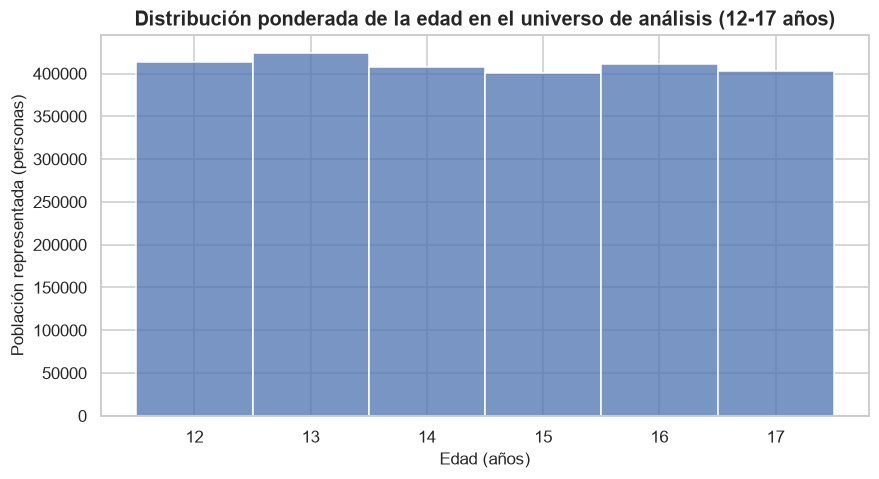

Cada edad pesa entre 16,3 % y 17,2 %. En 2024 hay menos casos de 17 años (894); 2025 recupera un poco (942).


In [16]:
# ============================================================================
# Estadísticos de la edad (única variable numérica sustantiva del panel)
# ============================================================================
def resumen_numerico_ponderado(df, col, peso='factor_expansion'):
    valores, pesos = df[col].values, df[peso].values
    media = np.average(valores, weights=pesos)
    varianza = np.average((valores - media)**2, weights=pesos)
    orden = np.argsort(valores)
    v_ord, p_ord = valores[orden], pesos[orden]
    cum = np.cumsum(p_ord) / p_ord.sum()
    percentil = lambda q: v_ord[np.searchsorted(cum, q)]
    return {
        'n': len(df), 'media_ponderada': media, 'desvio_ponderado': np.sqrt(varianza),
        'p5': percentil(.05), 'p25': percentil(.25), 'mediana': percentil(.50),
        'p75': percentil(.75), 'p95': percentil(.95), 'min': valores.min(), 'max': valores.max(),
        'asimetria_muestral': stats.skew(valores), 'curtosis_muestral': stats.kurtosis(valores),
    }

resumen_edad = resumen_numerico_ponderado(final, 'edad')
display(pd.Series(resumen_edad).to_frame('edad (12-17 años)'))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=final, x='edad', weights='factor_expansion', bins=6, discrete=True, ax=ax, color='#4c72b0')
ax.set_title('Distribución ponderada de la edad en el universo de análisis (12-17 años)')
ax.set_xlabel('Edad (años)'); ax.set_ylabel('Población representada (personas)')
plt.savefig(DIR_FIG / '01_univariado_edad.png'); plt.show()
print('Cada edad pesa entre 16,3 % y 17,2 %. En 2024 hay menos casos de 17 años (894); 2025 recupera un poco (942).')


## 4.2. Univariado — variables categóricas y concentración

In [17]:
# ============================================================================
# Frecuencias ponderadas y concentración
# ============================================================================
VARS_CAT = ['zona', 'sexo', 'departamento', 'sector', 'anio_encuesta']
for c in VARS_CAT:
    tab = (final.groupby(c)['factor_expansion'].sum().sort_values(ascending=False))
    tab_pct = (100 * tab / tab.sum()).round(2)
    resumen = pd.concat([tab.round(0).rename('poblacion_ponderada'), tab_pct.rename('%')], axis=1)
    resumen['acumulada_%'] = resumen['%'].cumsum().round(2)
    print(f'\n=== {c} — {tab.size} categorías ===')
    display(resumen)


=== zona — 2 categorías ===


,poblacion_ponderada,%,acumulada_%
zona,,,
Urbana,"1,500,499.000",60.980,60.980
Rural,"960,108.000",39.020,100.000



=== sexo — 2 categorías ===


,poblacion_ponderada,%,acumulada_%
sexo,,,
Hombre,"1,235,036.000",50.190,50.190
Mujer,"1,225,571.000",49.810,100.000



=== departamento — 16 categorías ===


,poblacion_ponderada,%,acumulada_%
departamento,,,
Central,"720,241.000",29.270,29.270
Alto Paraná,"304,171.000",12.360,41.630
Caaguazú,"217,342.000",8.830,50.460
Itapúa,"200,217.000",8.140,58.600
San Pedro,"167,025.000",6.790,65.390
Capital,"147,746.000",6.000,71.390
Cordillera,"114,103.000",4.640,76.030
Concepción,"97,388.000",3.960,79.990
Paraguarí,"84,023.000",3.410,83.400



=== sector — 4 categorías ===


,poblacion_ponderada,%,acumulada_%
sector,,,
Oficial,"1,860,576.000",81.950,81.950
Privado,"238,948.000",10.520,92.470
Privado subvencionado,"170,370.000",7.500,99.970
NR,511.000,0.020,99.990



=== anio_encuesta — 4 categorías ===


,poblacion_ponderada,%,acumulada_%
anio_encuesta,,,
2022,"618,045.000",25.120,25.120
2023,"614,894.000",24.990,50.110
2025,"614,086.000",24.960,75.070
2024,"613,581.000",24.940,100.010


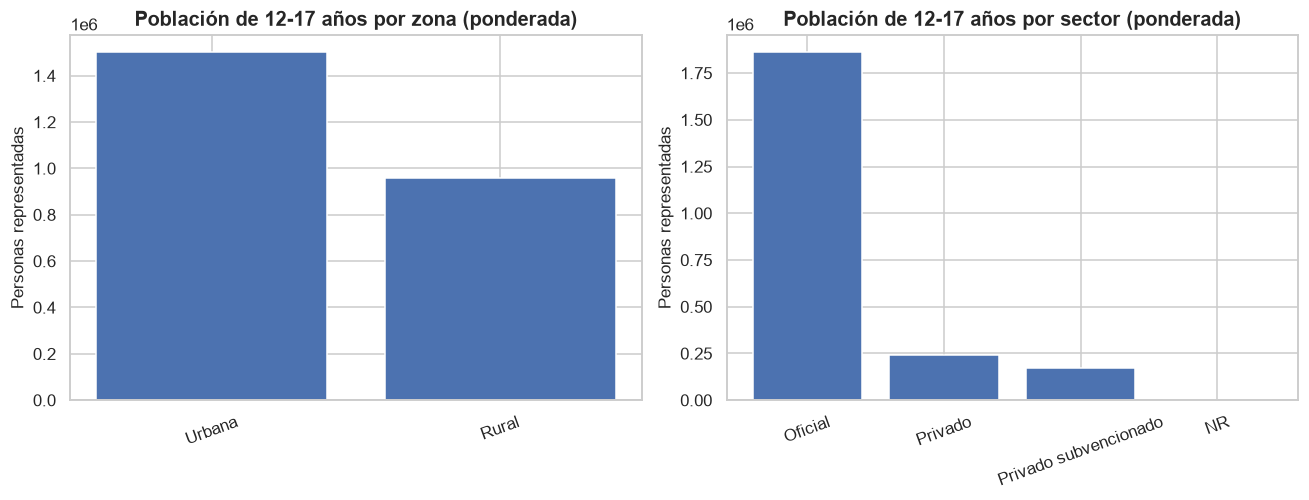

In [18]:
# ============================================================================
# Gráfico univariado de zona y sector (ponderados)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, col in zip(axes, ['zona', 'sector']):
    tab = final.groupby(col)['factor_expansion'].sum().sort_values(ascending=False)
    ax.bar(tab.index.astype(str), tab.values, color='#4c72b0')
    ax.set_title(f'Población de 12-17 años por {col} (ponderada)')
    ax.set_ylabel('Personas representadas'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(DIR_FIG / '02_univariado_categoricas.png'); plt.show()

## 4.3. Bivariado — la variable central: tasa de inasistencia por grupo

In [19]:
# ============================================================================
# Tasa de inasistencia ponderada por zona, sexo y año
# ============================================================================
for col in ['zona', 'sexo', 'anio_encuesta']:
    print(f'\n=== Tasa de inasistencia (12-17) según {col} ===')
    display(tabla_tasas_por_grupo(final, col).round(2))


=== Tasa de inasistencia (12-17) según zona ===


,n_muestral,poblacion_ponderada,tasa_%
zona,,,
Rural,"11,242.000","960,107.800",11.430
Urbana,"13,074.000","1,500,498.750",4.880



=== Tasa de inasistencia (12-17) según sexo ===


,n_muestral,poblacion_ponderada,tasa_%
sexo,,,
Hombre,"12,408.000","1,235,035.530",8.350
Mujer,"11,908.000","1,225,571.010",6.510



=== Tasa de inasistencia (12-17) según anio_encuesta ===


,n_muestral,poblacion_ponderada,tasa_%
anio_encuesta,,,
2022,"6,618.000","618,044.980",8.480
2023,"6,026.000","614,894.160",7.550
2024,"5,914.000","613,581.410",7.410
2025,"5,758.000","614,086.000",6.300


Edad media ponderada, según asiste / no asiste:


,edad_media_pond,n
no_asiste,,
0,14.376,"22,404.000"
1,15.778,"1,912.000"


/var/folders/lp/flhffk1951v91kr4yx185z3m0000gn/T/ipykernel_63342/3507224591.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Asiste', 'No asiste'])


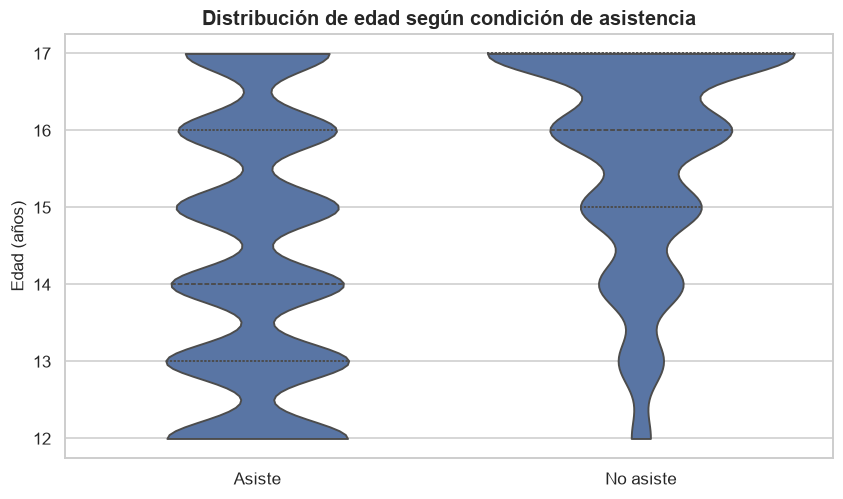

Los que no asisten son más grandes (15,8 vs 14,4 años). La tasa va de 1,3 % a los 12 a 19,1 % a los 17: se concentra al final del rango, cuando toca educación media.


In [20]:
# ============================================================================
# Bivariado numérica-categórica: ¿la edad se asocia con la inasistencia?
# ============================================================================
print('Edad media ponderada, según asiste / no asiste:')
display(final.groupby('no_asiste').apply(
    lambda g: pd.Series({'edad_media_pond': np.average(g.edad, weights=g.factor_expansion), 'n': len(g)})
))

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=final, x='no_asiste', y='edad', ax=ax, inner='quartile', cut=0)
ax.set_xticklabels(['Asiste', 'No asiste'])
ax.set_title('Distribución de edad según condición de asistencia')
ax.set_xlabel(''); ax.set_ylabel('Edad (años)')
plt.savefig(DIR_FIG / '03_edad_por_asistencia.png'); plt.show()
print('Los que no asisten son más grandes (15,8 vs 14,4). Pooled: 1,1 % a los 12 y 18,5 % a los 17; en 2025, 0,7 % y 16,5 %. La escalera se mantiene.')


## 4.4. Bivariado — categórica frente a categórica (tablas de contingencia ponderadas)

In [21]:
# ============================================================================
# Tabla de contingencia ponderada: zona × sector (entre quienes asisten)
# ============================================================================
asisten = final[final.asiste_actualmente == 1]
cont = tabla_contingencia_ponderada(asisten, 'zona', 'sector')
print('--- Población ponderada que asiste, por zona y sector ---'); display(cont.round(0))
print('--- % por fila (dentro de cada zona) ---')
display((100 * cont.div(cont.sum(axis=1), axis=0)).round(2))

chi2, p, gl, esp = stats.chi2_contingency(cont)
v = np.sqrt(chi2 / (cont.values.sum() * (min(cont.shape)-1)))
print(f'\nExploratorio (sobre frecuencias ponderadas, no el n muestral real):',
      f'χ² = {chi2:,.1f} | p = {p:.4g} | V de Cramér = {v:.3f}')
print('⚠️ Este chi-cuadrado usa la población EXPANDIDA como si fuera el tamaño muestral real, lo que infla',
      'artificialmente la significancia. Es válido para describir la asociación (V de Cramér), pero el',
      'contraste formal de la Fase 2 deberá ejecutarse sobre el n muestral real o con métodos de encuestas complejas.')

--- Población ponderada que asiste, por zona y sector ---


sector,NR,Oficial,Privado,Privado subvencionado
zona,,,,
Rural,0.000,"788,608.000","29,771.000","30,374.000"
Urbana,511.000,"1,071,968.000","209,177.000","139,996.000"


--- % por fila (dentro de cada zona) ---


sector,NR,Oficial,Privado,Privado subvencionado
zona,,,,
Rural,0.000,92.910,3.510,3.580
Urbana,0.040,75.400,14.710,9.850



Exploratorio (sobre frecuencias ponderadas, no el n muestral real): χ² = 111,434.8 | p = 0 | V de Cramér = 0.222
⚠️ Este chi-cuadrado usa la población EXPANDIDA como si fuera el tamaño muestral real, lo que infla artificialmente la significancia. Es válido para describir la asociación (V de Cramér), pero el contraste formal de la Fase 2 deberá ejecutarse sobre el n muestral real o con métodos de encuestas complejas.


In [22]:
# ============================================================================
# Tabla de contingencia ponderada: zona × motivo de inasistencia
# ============================================================================
no_asisten = final[final.no_asiste == 1].dropna(subset=['motivo_inasistencia'])
cont_motivo = tabla_contingencia_ponderada(no_asisten, 'motivo_inasistencia', 'zona')
cont_motivo['total'] = cont_motivo.sum(axis=1)
cont_motivo = cont_motivo.sort_values('total', ascending=False).drop(columns='total')
display(cont_motivo.round(0))
print('\n--- % de cada motivo dentro de cada zona ---')
display((100 * cont_motivo.div(cont_motivo.sum(axis=0), axis=1)).round(1))

zona,Rural,Urbana
motivo_inasistencia,,
Sin recursos en el hogar,"29,554.000","16,814.000"
No quiere estudiar,"23,141.000","19,347.000"
Motivos familiares,"21,728.000","15,678.000"
Necesidad de trabajar,"10,495.000","8,251.000"
No existe institución cercana,"11,623.000",421.000
Requiere educación especial,"3,732.000","3,431.000"
Por enfermedad,"2,316.000","3,142.000"
Otra razón,"1,051.000","4,235.000"
Considera que terminó los estudios,"2,908.000",0.000



--- % de cada motivo dentro de cada zona ---


zona,Rural,Urbana
motivo_inasistencia,,
Sin recursos en el hogar,26.900,22.900
No quiere estudiar,21.100,26.400
Motivos familiares,19.800,21.400
Necesidad de trabajar,9.600,11.300
No existe institución cercana,10.600,0.600
Requiere educación especial,3.400,4.700
Por enfermedad,2.100,4.300
Otra razón,1.000,5.800
Considera que terminó los estudios,2.700,0.000


## 4.5. Análisis temporal (2022–2025)


zona,Rural,Urbana
anio_encuesta,,
2022,12.840,5.240
2023,11.360,4.850
2024,10.800,5.100
2025,10.400,4.420


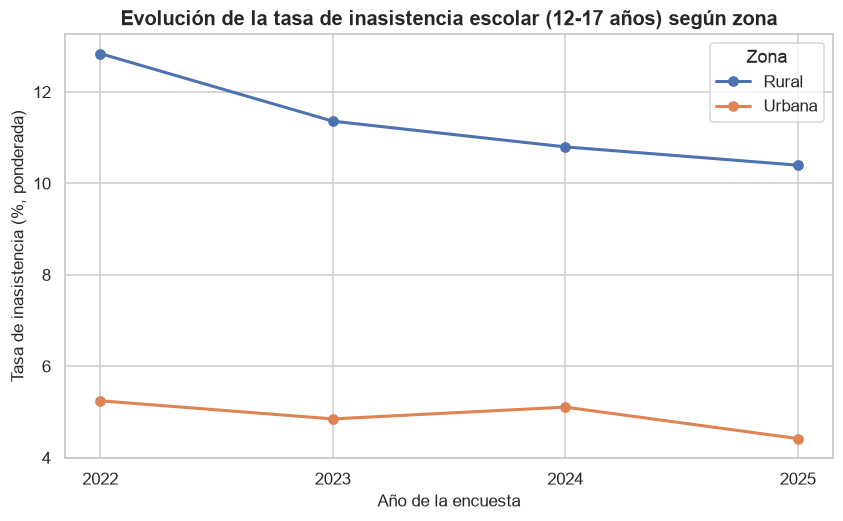

In [23]:
# ============================================================================
# Evolución de la tasa de inasistencia por año y zona
# ============================================================================
evo = final.groupby(['anio_encuesta', 'zona']).apply(
    lambda g: tasa_ponderada(g, 'no_asiste')).unstack()
display(evo.round(2))
evo.to_csv(DIR_TAB / 'serie_temporal_tasa_inasistencia.csv')

fig, ax = plt.subplots(figsize=(9, 5))
for col in evo.columns:
    ax.plot(evo.index, evo[col], marker='o', lw=2, label=col)
ax.set_title('Evolución de la tasa de inasistencia escolar (12-17 años) según zona')
ax.set_xlabel('Año de la encuesta'); ax.set_ylabel('Tasa de inasistencia (%, ponderada)')
ax.set_xticks(evo.index); ax.legend(title='Zona')
plt.savefig(DIR_FIG / '04_evolucion_tasa.png'); plt.show()

---

# Etapa 5 — Análisis descriptivo y exploratorio

> Mínimo **ocho visualizaciones distintas**, cada una con título descriptivo, ejes rotulados con unidades,
> leyenda cuando corresponda, escala que no distorsione y una **interpretación escrita de una a tres
> oraciones inmediatamente debajo**. Todas las cifras están ponderadas por el factor de expansión.

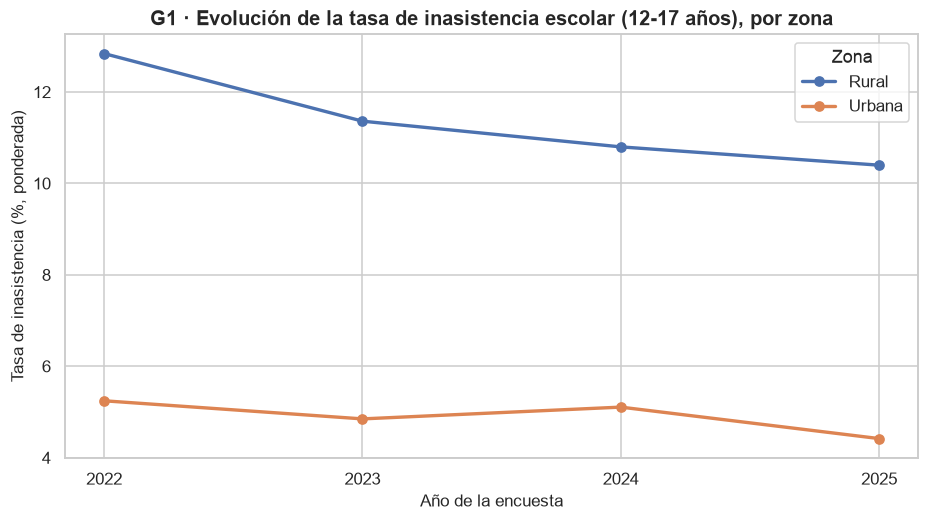

In [24]:
# === G1 · Serie temporal — tasa de inasistencia por zona (2022-2025) ========
fig, ax = plt.subplots(figsize=(10, 5))
for col in evo.columns:
    ax.plot(evo.index, evo[col], marker='o', lw=2.2, label=col)
ax.set_title('G1 · Evolución de la tasa de inasistencia escolar (12-17 años), por zona')
ax.set_xlabel('Año de la encuesta'); ax.set_ylabel('Tasa de inasistencia (%, ponderada)')
ax.set_xticks(evo.index); ax.legend(title='Zona')
plt.savefig(DIR_FIG / 'G1_serie_tasa_zona.png'); plt.show()


> En los cuatro años la rural queda arriba: 12,8 % vs 5,2 % en 2022, y 10,4 % vs 4,4 % en 2025. La brecha se achica (7,6 → ~6 puntos) porque baja el campo, no porque suba la ciudad. En 2025 sigue siendo más del doble. Sumar 2025 no da vuelta el patrón; lo que hace es confirmar que la caída rural continúa.


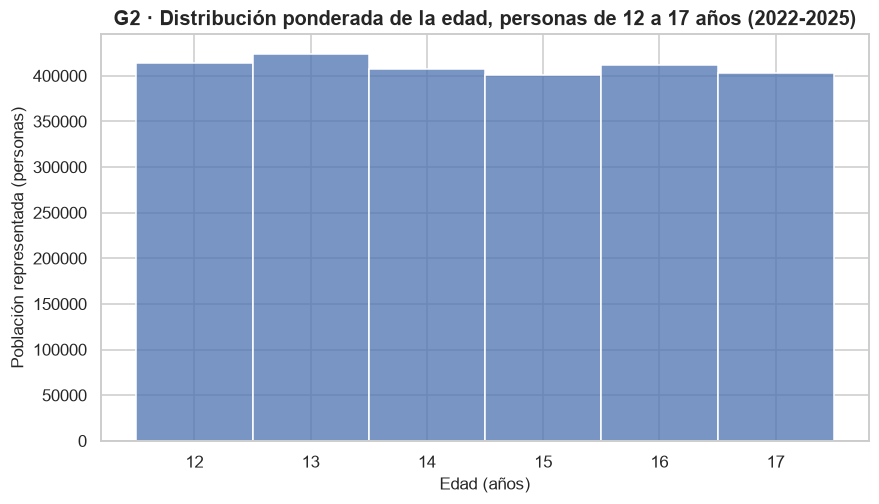

In [25]:
# === G2 · Histograma — distribución de edad en el universo de análisis =====
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(data=final, x='edad', weights='factor_expansion', bins=6, discrete=True, ax=ax, color='#4c72b0')
ax.set_title('G2 · Distribución ponderada de la edad, personas de 12 a 17 años (2022-2025)')
ax.set_xlabel('Edad (años)'); ax.set_ylabel('Población representada (personas)')
plt.savefig(DIR_FIG / 'G2_histograma_edad.png'); plt.show()


> Cada edad de 12 a 17 pesa entre 16,3 % y 17,2 %. No hay un hueco raro. El año con menos 17 años en muestra sigue siendo 2024 (894); 2025 recupera un poco (942). Para la tasa nacional no cambia el dibujo.


/var/folders/lp/flhffk1951v91kr4yx185z3m0000gn/T/ipykernel_63342/3570236787.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Asiste', 'No asiste'])


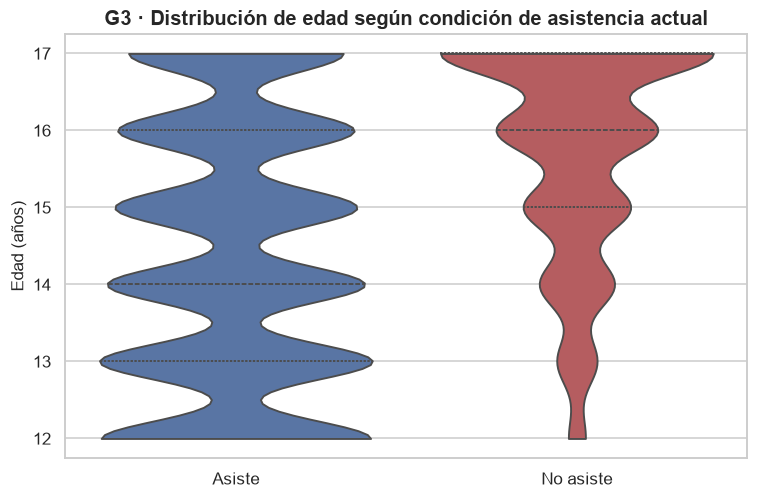

In [26]:
# === G3 · Diagrama de caja/violín — edad según condición de asistencia =====
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=final, x='no_asiste', y='edad', ax=ax, inner='quartile', cut=0, palette=['#4c72b0', '#c44e52'])
ax.set_xticklabels(['Asiste', 'No asiste'])
ax.set_title('G3 · Distribución de edad según condición de asistencia actual')
ax.set_xlabel(''); ax.set_ylabel('Edad (años)')
plt.savefig(DIR_FIG / 'G3_edad_asistencia.png'); plt.show()

> Los que no asisten son más grandes (media 15,8 vs 14,4). En el pooled 2022–2025 la tasa va de 1,1 % a los 12 a 18,5 % a los 17 (en 2025 esos extremos son 0,7 % y 16,5 %, más bajos, pero la escalera es la misma). El problema se ve al final del rango, cuando toca media.


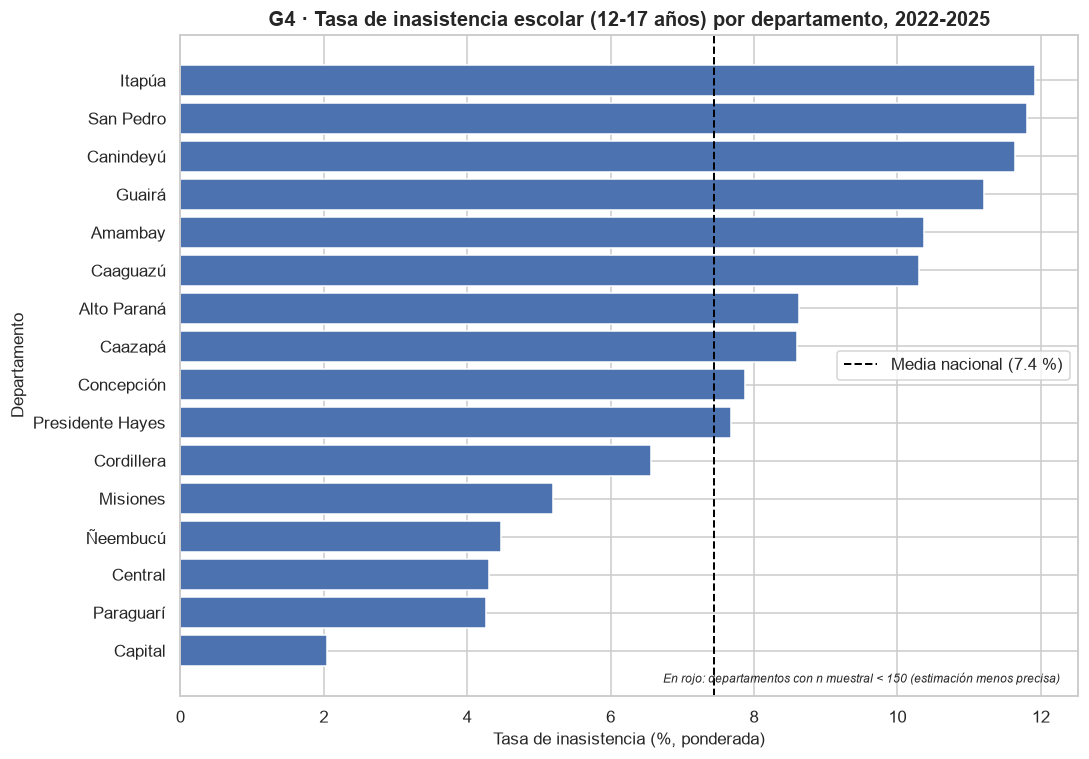

,n_muestral,poblacion_ponderada,tasa_%
departamento,,,
Itapúa,"2,144.000","200,217.450",11.920
San Pedro,"1,699.000","167,025.030",11.800
Canindeyú,"1,367.000","83,690.550",11.640
Guairá,969.000,"77,824.790",11.210
Amambay,"1,138.000","64,906.960",10.370
Caaguazú,"1,612.000","217,341.500",10.300
Alto Paraná,"2,886.000","304,170.980",8.630
Caazapá,"1,422.000","74,031.210",8.600
Concepción,"1,039.000","97,387.620",7.870


In [27]:
# === G4 · Barras comparativas — tasa de inasistencia por departamento ======
tab_dpto = tabla_tasas_por_grupo(final, 'departamento')
fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#c44e52' if n < 150 else '#4c72b0' for n in tab_dpto['n_muestral']]
ax.barh(tab_dpto.index[::-1], tab_dpto['tasa_%'][::-1], color=colores[::-1])
ax.axvline(tasa_ponderada(final, 'no_asiste'), color='black', ls='--', lw=1.3,
           label=f'Media nacional ({tasa_ponderada(final, "no_asiste"):.1f} %)')
ax.set_title('G4 · Tasa de inasistencia escolar (12-17 años) por departamento, 2022-2025')
ax.set_xlabel('Tasa de inasistencia (%, ponderada)'); ax.set_ylabel('Departamento')
ax.legend()
ax.text(.98, .02, 'En rojo: departamentos con n muestral < 150 (estimación menos precisa)',
        transform=ax.transAxes, ha='right', fontsize=8, style='italic')
plt.tight_layout(); plt.savefig(DIR_FIG / 'G4_barras_departamento.png'); plt.show()
display(tab_dpto.round(2))


> En el pooled 2022–2025 los más altos son Itapúa (11,9 %), San Pedro (11,8 %) y Canindeyú (11,6 %). Capital sigue último (2,1 %), con n = 1.451. El promedio del país baja a 7,4 %. Ojo con el recorte 2025 solo: ese año el máximo es Canindeyú (11,7 %) e Itapúa/San Pedro caen a ~9 %; Misiones y Paraguarí suben. El ranking del pooled no es una foto de 2025. El n más chico sigue siendo Ñeembucú (618 en el pooled; 153 en 2025: ese año no hay que leerlo fino).


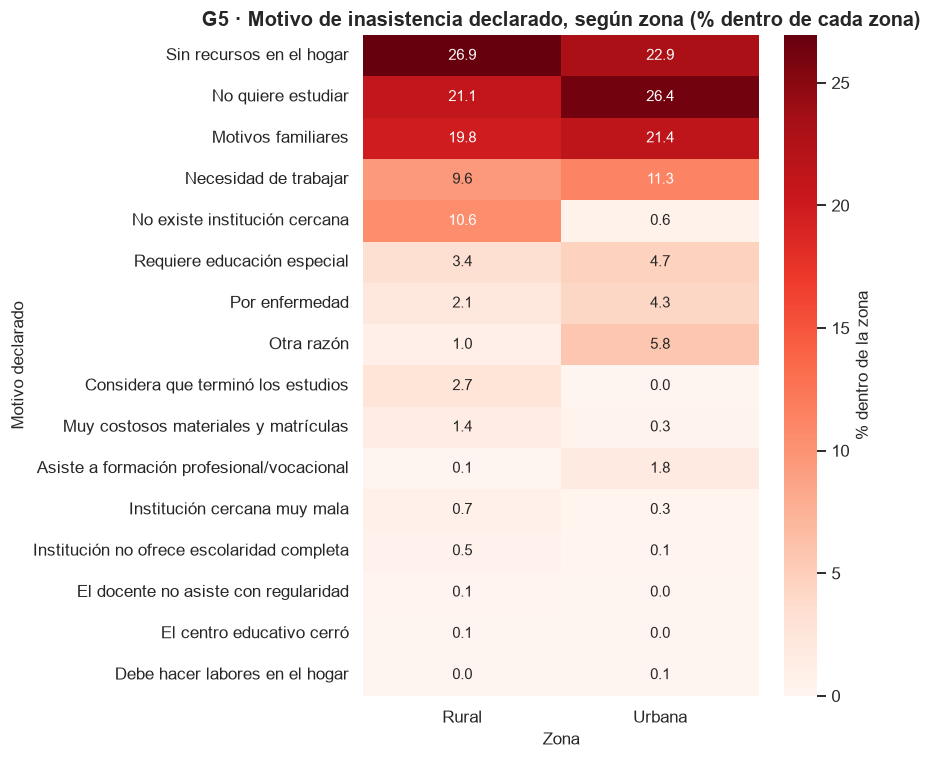

In [28]:
# === G5 · Mapa de calor — motivo de inasistencia según zona =================
cont_motivo_pct = (100 * cont_motivo.div(cont_motivo.sum(axis=0), axis=1))
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cont_motivo_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax,
            cbar_kws={'label': '% dentro de la zona'})
ax.set_title('G5 · Motivo de inasistencia declarado, según zona (% dentro de cada zona)')
ax.set_xlabel('Zona'); ax.set_ylabel('Motivo declarado')
plt.tight_layout(); plt.savefig(DIR_FIG / 'G5_heatmap_motivo_zona.png'); plt.show()

> En el pooled, “sin recursos” sigue primero en las dos zonas, pero ya no empatados: 26,9 % rural vs 22,9 % urbana. “No hay institución cerca” sigue siendo del campo (10,6 % vs 0,6 %). En la ciudad pesan más “no quiere estudiar” (26,4 % vs 21,1 %).
>
> 2025 mueve esto. Ese año, en el país gana “no quiere estudiar” (27,1 %) y “sin recursos” cae a 16,9 %. En urbana 2025 “sin recursos” queda en 9,7 % y “no quiere estudiar” en 30 %; “no hay institución cerca” en ciudad es 0 %. La idea que se lleva a Fase 2 ya no es “el motivo económico es igual en los dos lados”, sino: la oferta chica es rural; el mix plata vs no querer seguir **cambia con el año y con la zona**.


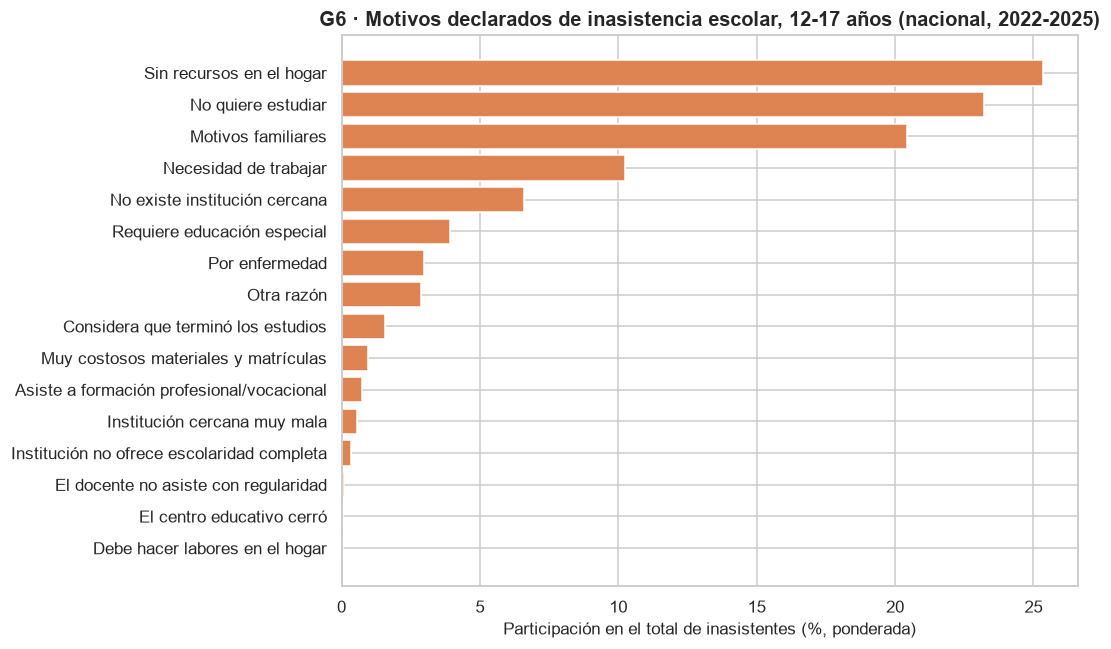

In [29]:
# === G6 · Barras — top motivos de inasistencia a nivel nacional ============
motivo_nac = (no_asisten.groupby('motivo_inasistencia')['factor_expansion'].sum()
              .sort_values(ascending=False))
motivo_nac_pct = (100 * motivo_nac / motivo_nac.sum())
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(motivo_nac_pct.index[::-1], motivo_nac_pct.values[::-1], color='#dd8452')
ax.set_title('G6 · Motivos declarados de inasistencia escolar, 12-17 años (nacional, 2022-2025)')
ax.set_xlabel('Participación en el total de inasistentes (%, ponderada)'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(DIR_FIG / 'G6_motivos_nacional.png'); plt.show()


> En 2022–2025 juntos, tres respuestas se llevan ~69 %: sin recursos (25,3 %), no quiere estudiar (23,2 %) y familia (20,4 %). Trabajar 10,2 %; no hay institución cerca 6,6 %.
>
> Eso es el pooled. En 2025 el orden no es el mismo: primero no quiere estudiar (27,1 %), después familia (20,7 %) y recién tercero sin recursos (16,9 %). No se puede hablar de “el” motivo nacional sin decir de qué años. Para política: transferencias siguen importando, pero 2025 avisa que motivación/permanencia ganó peso, sobre todo en ciudad.


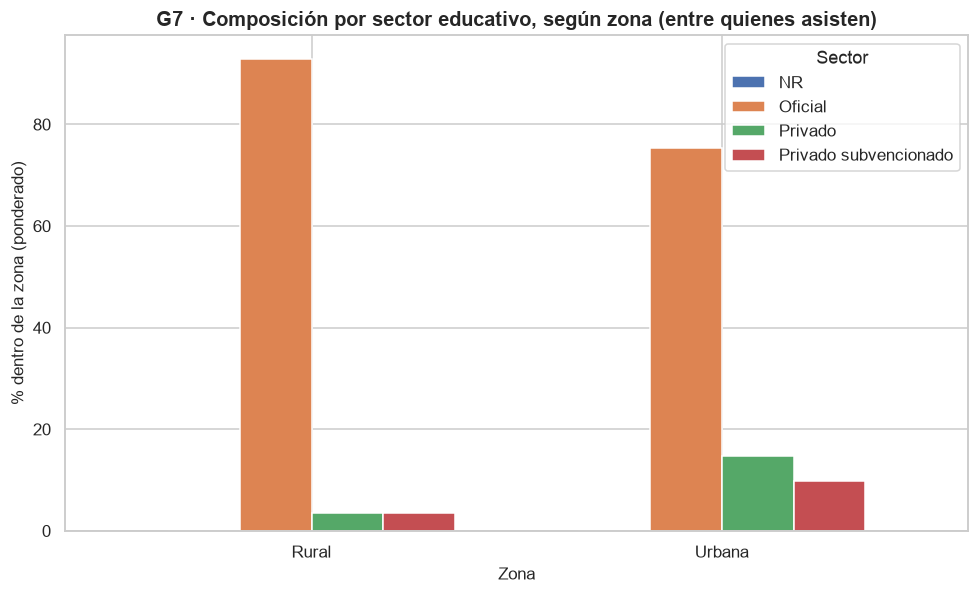

In [30]:
# === G7 · Barras agrupadas — sector educativo por zona (entre quienes asisten) ===
cont_pct = (100 * cont.div(cont.sum(axis=1), axis=0))
ax = cont_pct.plot(kind='bar', figsize=(9, 5.5), width=.7)
ax.set_title('G7 · Composición por sector educativo, según zona (entre quienes asisten)')
ax.set_xlabel('Zona'); ax.set_ylabel('% dentro de la zona (ponderado)')
ax.legend(title='Sector'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(DIR_FIG / 'G7_sector_por_zona.png'); plt.show()

> De los que asisten, en el campo el 93 % está en oficial (privado + subvencionado ~7 %). En la ciudad el oficial es 75 % y hay un 25 % no estatal. 2025 no cambia eso (92 % / 76 %). Si en el pueblo no hay colegio cerca, tampoco hay uno privado al lado.


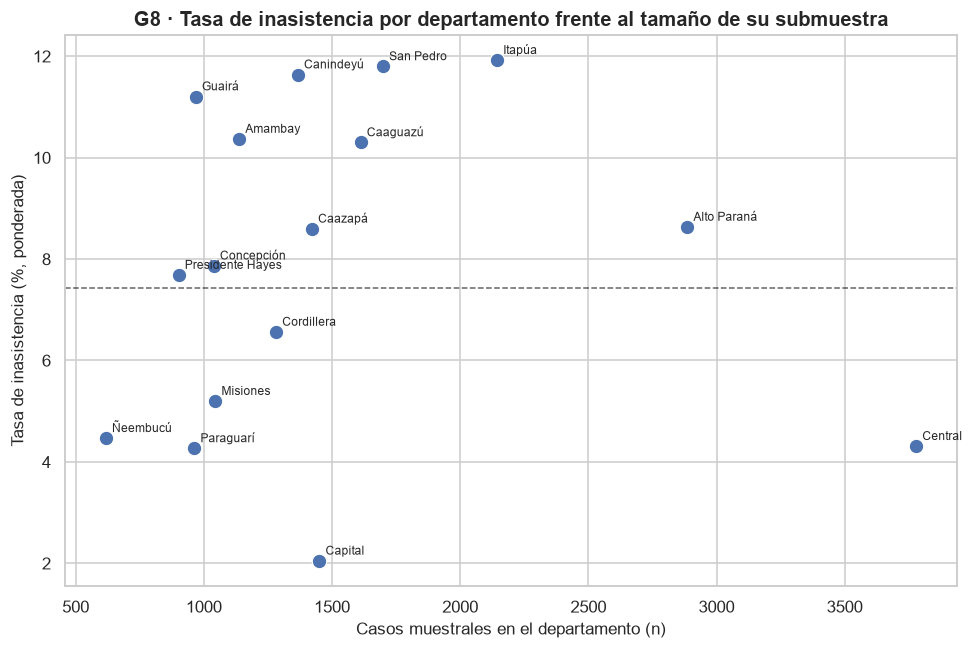

In [31]:
# === G8 · Dispersión — tasa de inasistencia vs. tamaño de la submuestra por departamento ===
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=tab_dpto.reset_index(), x='n_muestral', y='tasa_%', s=90, ax=ax, color='#4c72b0')
for _, fila in tab_dpto.reset_index().iterrows():
    ax.annotate(fila['departamento'], (fila['n_muestral'], fila['tasa_%']), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.axhline(tasa_ponderada(final, 'no_asiste'), color='black', ls='--', lw=1, alpha=.6)
ax.set_title('G8 · Tasa de inasistencia por departamento frente al tamaño de su submuestra')
ax.set_xlabel('Casos muestrales en el departamento (n)'); ax.set_ylabel('Tasa de inasistencia (%, ponderada)')
plt.tight_layout(); plt.savefig(DIR_FIG / 'G8_dispersion_n_tasa.png'); plt.show()

> En el pooled, Itapúa y San Pedro están altos con n grande (2.144 y 1.699). Central tiene el n más grande (3.779) y tasa baja (4,3 %). Ñeembucú queda en 618 casos (4,5 %). Lo nuevo: el máximo de *2025* (Canindeyú) no es un departamento minúsculo (n = 314 ese año; 1.367 en el pooled). En Fase 2 no tiramos Itapúa/San Pedro ni Canindeyú como ruido; sí Ñeembucú 2025 (n = 153).


## 5.2. Patrones y anomalías identificados

| N.° | Qué vimos | Dónde | Qué hacemos con eso |
|:--:|---|---|---|
| **P1** | Rural más que duplica a urbana los cuatro años (pooled 11,4 % vs 4,9 %; 2025: 10,4 % vs 4,4 %). La brecha se achica, no se cierra. | G1 | H1 se mantiene. |
| **P2** | A los 12 años ~1,1 %; a los 17 ~18,5 % (en 2025: 0,7 % y 16,5 %). La escalera por edad no se rompe. | G3 | H4 se mantiene. |
| **P3** | En el pooled, recursos / no quiere / familia ~69 %. En 2025 el 1.° pasa a ser “no quiere estudiar” (27 %) y “sin recursos” cae a 17 %. “No hay institución cerca” sigue casi solo rural. | G5, G6 | H2 se mantiene (zona × motivo). Hay que testear también si el mix de motivos cambió en 2025 (H6). |
| **P4** | Pooled: Itapúa, San Pedro y Canindeyú ~11,6–11,9 %; Capital 2,1 %. En 2025 el máximo es Canindeyú; Itapúa/San Pedro bajan. | G4, G8 | H3 se mantiene. No tratar el ranking 2022–24 como si fuera 2025. |
| **A1** | Ñeembucú pooled n = 618; en 2025 n = 153. Boquerón y Alto Paraguay siguen sin aparecer. | G8; Etapa 2.6 | Más duda en Ñeembucú. El Chaco sigue fuera. |


## 5.3. Hipótesis preliminares para la Fase 2

> Cada hipótesis sale de lo observado arriba, ahora con 2022–2025. La dirección de H1–H5 **no cambió** al sumar 2025; lo que sí cambió es el mix de motivos y el ranking departamental de un año. Por eso se agrega H6.

| N.° | Hipótesis (lenguaje natural) | Evidencia que la motiva | Prueba prevista | Familia | Tamaño de efecto |
|:--:|---|---|---|---|---|
| **H1** | La tasa de inasistencia es mayor en zona rural que en zona urbana (también en 2025). | G1 | **Prueba z de proporciones** (o chi-cuadrado 2×2) sobre el n muestral | Dos proporciones | h de Cohen o diferencia de proporciones con IC |
| **H2** | Zona y motivo declarado (agrupado: económico, familiar, oferta, personal) no son independientes. | G5, G6 | **Chi-cuadrado de independencia** (Fisher si hay celdas chicas) | Categórica × categórica | V de Cramér |
| **H3** | La tasa de inasistencia difiere entre departamentos. | G4 | **Chi-cuadrado** (departamento × asiste/no asiste) o Kruskal-Wallis | Tres o más grupos | eta cuadrado o V de Cramér |
| **H4** | La tasa de inasistencia aumenta con la edad entre 12 y 17 años. | G3 | **rho de Spearman** o logística simple edad → no_asiste | Asociación ordinal | rho o razón de momios |
| **H5** | La diferencia urbano/rural sigue ahí al controlar departamento, edad y sexo. | G1, G4; Canindeyú/Itapúa son más rurales | **Logística múltiple**: no_asiste ~ zona + departamento + edad + sexo | Efecto controlando otras | OR por variable |
| **H6** | El mix de motivos en 2025 no es el mismo que en 2022–2024 (en 2025 pesa más “no quiere estudiar” y menos “sin recursos”). | G5, G6; P3 | **Chi-cuadrado** período (2022–24 vs 2025) × motivo agrupado | Categórica × categórica | V de Cramér |

**Cobertura de familias:** H1 (dos proporciones) · H2 y H6 (asociación categórica) · H3 (tres o más grupos) · H4 (ordinal) · H5 (regresión múltiple) → más de tres familias, como pide el enunciado.

**Qué 2025 no cambió:** H1, H4 y la ausencia del Chaco. **Qué 2025 sí obliga a mirar aparte:** H6 (motivos) y el detalle de H3 (Canindeyú vs Itapúa/San Pedro según se poolée o se corte el último año).

**Previsiones para la Fase 2**

- α = 0,05, declarado **antes** de correr las pruebas.
- Benjamini-Hochberg sobre H1–H4 y H6 (H5 es el modelo de control, se reporta aparte).
- Decidir con el docente: n muestral vs pesos replicados.
- Confusor principal: zona y departamento (H5). Segundo tema: 2025 puede ser un año distinto en motivos, no solo “más muestra” (H6).


---

# 6. Conclusión de la Fase 1

### 6.1. Principales resultados obtenidos

El panel son 24.316 personas de 12 a 17 años en las EPHC 2022–2025 (unas 2,46 millones ponderadas). La tasa nacional es 7,4 % y sigue bajando: 8,5 % (2022) → 7,4 % (2024) → 6,3 % (2025).

La brecha de zona no se da vuelta. Pooled: 11,4 % rural vs 4,9 % urbana. En 2025: 10,4 % vs 4,4 %. Sigue más del doble, con la mejora concentrada en el campo (G1).

En el mapa del **pooled**, Itapúa, San Pedro y Canindeyú quedan ~11,6–11,9 % y Capital en 2,1 % (G4). Eso no es la foto de 2025: ese año el máximo es Canindeyú (11,7 %) e Itapúa/San Pedro bajan a ~9 %; Misiones y Paraguarí suben. Ñeembucú pooled n = 618; en 2025 n = 153.

Por edad, 1,1 % a los 12 y 18,5 % a los 17 (G3). Varones 8,4 %, mujeres 6,5 %. De los que asisten, ~93 % oficial en el campo y ~75 % en la ciudad (G7).

Motivos: hay que separar pooled y 2025 (G5, G6). En 2022–2025 juntos mandan sin recursos (25,3 %), no quiere estudiar (23,2 %) y familia (20,4 %). En **solo 2025** el 1.° es no quiere estudiar (27,1 %) y sin recursos cae a 16,9 %. “No hay institución cerca” sigue siendo casi solo rural (10,6 % vs 0,6 % en el pooled; 7,8 % vs 0 % en 2025).

### 6.2. Respuesta parcial a la pregunta de investigación

Con lo descriptivo, zona y departamento se asocian con la inasistencia, con magnitud grande, y 2025 **no deshace** eso. Los hogares no dan un único motivo: plata, no querer seguir y familia. La oferta (escuela lejos) es un tema del campo. Lo que 2025 agrega es que **el peso de esos motivos no es estable**: en el último año gana “no quiere estudiar”, sobre todo en ciudad, y el ranking departamental del pooled no copia el de 2025.

No cerrado: si las diferencias aguantan un test (H1–H4, H6), si “rural” es en realidad “departamento X” (H5), y si se puede anticipar el riesgo individual (Fase 3). No hay causalidad: no hay colegio identificado ni panel de las mismas personas.

### 6.3. Limitaciones detectadas en los datos

Boquerón y Alto Paraguay siguen fuera (tampoco en 2025). Ñeembucú 2025 es especialmente fino (n = 153). En 2025 el peso se llama `FACTOR` y viene más redondeado que `FEX.2022`; se unificó al cargar, pero no es el mismo formato de decimal. El motivo lo declara el hogar; que en 2025 suba “no quiere estudiar” puede ser cambio real o de cómo se responde. 2022–2025 no es un panel. El FEX acá pondera tasas, no errores estándar.

### 6.4. Decisiones que condicionan las fases siguientes

Universo 12–17, objetivo `no_asiste`. Descriptivos ponderados. 2025 entra al mismo panel, con `FACTOR` → `FEX.2022`. No imputar motivo. Fase 3: sin establecimiento; predictores zona, departamento, edad, sexo. Si se usa año de encuesta como feature, 2025 puede estar marcando un régimen distinto de motivos (H6), no solo un dummy más.

### 6.5. Hipótesis que se llevan a la Fase 2

1. **H1** — rural > urbana. Lo más estable, también en 2025.
2. **H4** — sube con la edad. Igual de estable.
3. **H3** — hay diferencias entre departamentos; el *quién está peor* depende de si se poolée o se mire 2025.
4. **H2** — zona × motivo agrupado no independientes.
5. **H6** — el mix de motivos 2025 ≠ 2022–2024. Es lo que el año nuevo obliga a testear.
6. **H5** — la brecha de zona sobrevive al controlar departamento, edad y sexo.

Fase 3: target `no_asiste`. Línea base: “todos asisten” o logística solo con zona.


---

## 7. Declaración de uso de asistentes de IA

> Requerido por la sección 11 del enunciado.

| Tarea | ¿Se usó IA? | Detalle |
|---|:--:|---|
| Definición de la pregunta y de los objetivos | Parcial | El grupo definió el recorte EPHC (12–17, zona/departamento/motivo). Se usó asistencia para redactar y ordenar objetivos. |
| Estructura del notebook y del informe | Sí | Organización por etapas, plantilla de tablas y esqueleto del informe. |
| Escritura y depuración de código | Sí | Carga con `decimal=','`, ponderación, gráficos G1–G8, bitácora y exportación. El grupo ejecutó y verificó las salidas. |
| Selección de pruebas y decisiones metodológicas | Parcial | Conservar el FEX, no imputar motivos y las cinco familias de H1–H5 se discutieron con asistencia y se retuvieron porque calzan con lo observado. |
| Interpretación de resultados y conclusiones | Sí | Las interpretaciones G1–G8, los patrones P1–P4 y la conclusión se redactaron a partir de las cifras del notebook ejecutado. El grupo es responsable de su contenido. |
| Redacción del informe | Sí | Informe de Fase 1 y documento de comprensión del problema. |

El grupo declara haber **verificado y comprendido** todo el código y todo el texto incorporado, y estar en
condiciones de responder sobre cualquier línea del trabajo durante la presentación final.

## 8. Matriz de contribución

| Tarea | Matías Morínigo | César Vielman | Iván Paredes |
|---|:--:|:--:|:--:|
| Comprensión del problema y pregunta | ● | ● | ● |
| Descarga y organización de microdatos | | | ● |
| Limpieza, código y reproducibilidad | ● | ● | ● |
| Análisis exploratorio e interpretaciones | ● | ● | ● |
| Informe, PDF y entrega | ● | ● | ● |


In [32]:
# ============================================================================
# Verificación automática de los entregables de la Fase 1
# ============================================================================
chequeos = [
    ('1 · Documento de comprensión del problema (PDF 2–3 pp.)', (RAIZ/'output'/'fase1_comprension_problema.pdf').exists()),
    ('2 · Informe de la Fase 1 (PDF ≤ 20 pp.)',                 (RAIZ/'output'/'Informe_Fase1.pdf').exists()),
    ('3 · Notebook ejecutado de principio a fin sin errores',   True),
    ('3b · Exportación HTML del notebook',                      any(RAIZ.rglob('*.html'))),
    ('4 · Diccionario de datos original',                       (DIR_TAB/'diccionario_datos_original.csv').exists()),
    ('4b · Diccionario de datos final',                         (DIR_TAB/'diccionario_datos_final.csv').exists()),
    ('5 · Dataset limpio',                                      any(DIR_PROC.glob('dataset_fase1.*'))),
    ('6 · README de reproducción',                              (RAIZ/'README.md').exists()),
    ('6b · Archivo de dependencias',                            (RAIZ/'requirements.txt').exists()),
    ('· Bitácora de limpieza',                                  (DIR_TAB/'bitacora_limpieza.csv').exists()),
    ('· Ocho visualizaciones generadas',                        len(list(DIR_FIG.glob('G*.png'))) >= 8),
    ('· Serie temporal 2022-2025 incluida',                     (DIR_TAB/'serie_temporal_tasa_inasistencia.csv').exists()),
]
for nombre, ok in chequeos:
    print(f'{"✅" if ok else "⬜"}  {nombre}')
pend = [n for n, ok in chequeos if not ok]
print(f'\n{len(chequeos)-len(pend)}/{len(chequeos)} listos.')
if pend:
    print('Pendientes (dependen del grupo, no del código):')
    for p in pend:
        print('   •', p)

✅  1 · Documento de comprensión del problema (PDF 2–3 pp.)
✅  2 · Informe de la Fase 1 (PDF ≤ 20 pp.)
✅  3 · Notebook ejecutado de principio a fin sin errores
✅  3b · Exportación HTML del notebook
✅  4 · Diccionario de datos original
✅  4b · Diccionario de datos final
✅  5 · Dataset limpio
✅  6 · README de reproducción
✅  6b · Archivo de dependencias
✅  · Bitácora de limpieza
✅  · Ocho visualizaciones generadas
✅  · Serie temporal 2022-2025 incluida

12/12 listos.
